# Mini Project 2 — Part 2

**NetID: dpate172**

This notebook groups the Part 1 commits by month, plots activity, and measures
gaps. It creates ten monthly CSVs, ten PNG plots, and the Part 2 columns in
`dpate172_project_stats.csv`.

Months use UTC and run from each project's first to last dated commit, including
zero-commit months in between. The **13 undated records**
(12 in `microsoft_fhir-server`, one in `agnwinds_python`) cannot be assigned to a month.
Their missing dates could change those projects' counts, ranges, or gaps.

## Gap definitions

The longest gap is the longest consecutive run of zero-commit months, even if
it lasts only one or two months. `NumberOfGapsInTimeline` counts runs of at least
three months. Ties for the longest gap use the earliest run.

`NumCommitsAfterLastGap` follows the assignment's definition: commits after
**LongestGapEnd**, through the last dated commit in this dataset. With no gap,
its dates and post-gap count are blank, and its length and gap count are zero.
First and last months may be partial; the timelines are not extended to today.

## Monthly aggregation and plotting

Run from the repository folder with `requirements.txt` installed. The code below
uses the saved Part 1 data and makes no API requests. CSV columns are
`Month;#Commits`, with months written as `YYYY-MM`. Plots are saved at 320 DPI.

In [1]:
from pathlib import Path
from IPython.display import Image, display
assert Path("dpate172_project_summary.csv").exists(), "Run from the repository folder."

In [2]:
#!/usr/bin/env python3
"""Aggregate Part 1 author timestamps into monthly activity and inactivity gaps.

Run with a reviewed interpretation map, for example:
    python scripts/analyze_part2.py --interpretations data/dpate172_interpretations.json

The map must provide an ActivityPattern for every project. This script does not
infer those visual interpretations. Missing timestamps remain missing and never
receive invented months. A project with no zero-commit month has blank gap dates,
gap length 0, and blank NumCommitsAfterLastGap (not applicable).
"""

import argparse
import csv
from datetime import datetime, timezone
import hashlib
import json
import os
from pathlib import Path
import re
import shutil

import pandas as pd


ROOT = Path(__file__).resolve().parents[1] if "__file__" in globals() else Path.cwd()
PART1_COLUMNS = ["Project", "ncommits", "nauthors", "from", "to", "nstars", "nforks", "lastGHCommitDate"]
PART2_COLUMNS = ["LongestGapStart", "LongestGapEnd", "LongestGapLength",
                 "NumCommitsAfterLastGap", "ActivityPattern", "NumberOfGapsInTimeline"]
PART3_COLUMNS = ["BeforeThemes", "AfterThemes", "HypothesizedGapReason", "HasRecovered",
                 "WhyRecovered", "WhoRecovered", "Currentstatus", "RecentThemes", "Notes"]
SUMMARY_COLUMNS = ["project_wocid", "commit_sha1", "author", "time", "commit message"]
MONTHLY_COLUMNS = ["Month", "#Commits"]
PATTERNS = {"steady", "rising", "declining", "U-shaped", "cyclical", "irregular"}
PLOT_DPI = 320  # PNG resolution metadata remains above 300 after unit conversion.


def read_csv(path):
    """Use csv so text, blank fields, and the original stats values stay exact."""
    csv.field_size_limit(10 * 1024 * 1024)
    with Path(path).open(newline="", encoding="utf-8-sig") as handle:
        reader = csv.DictReader(handle, delimiter=";")
        return reader.fieldnames, list(reader)


def write_csv(path, columns, rows):
    path = Path(path)
    temporary = path.with_suffix(path.suffix + ".tmp")
    with temporary.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=columns, delimiter=";", lineterminator="\n")
        writer.writeheader()
        writer.writerows(rows)
    temporary.replace(path)


def load_part1_data(summary_path, stats_path):
    """Return source rows and the unchanged eight-column Part 1 stats projection."""
    columns, rows = read_csv(summary_path)
    if columns != SUMMARY_COLUMNS:
        raise ValueError(f"Unexpected summary columns: {columns}")
    stats_columns, stats = read_csv(stats_path)
    if stats_columns not in (PART1_COLUMNS, PART1_COLUMNS + PART2_COLUMNS,
                            PART1_COLUMNS + PART2_COLUMNS + PART3_COLUMNS):
        raise ValueError(f"Unexpected stats columns: {stats_columns}")
    base_stats = [{column: row[column] for column in PART1_COLUMNS} for row in stats]
    projects = [row["Project"] for row in base_stats]
    if len(projects) != 10 or len(set(projects)) != 10:
        raise ValueError("Expected exactly ten distinct assigned projects")
    if set(row["project_wocid"] for row in rows) != set(projects):
        raise ValueError("Summary and stats project identifiers differ")
    pairs = [(row["project_wocid"], row["commit_sha1"]) for row in rows]
    if len(set(pairs)) != len(pairs):
        raise ValueError("Duplicate project/commit pairs in the Part 1 summary")
    for project in projects:
        source_count = sum(row["project_wocid"] == project for row in rows)
        expected = int(next(row["ncommits"] for row in base_stats if row["Project"] == project))
        if source_count != expected:
            raise ValueError(f"Part 1 count mismatch for {project}: {source_count} != {expected}")
    return rows, base_stats

In [3]:
def monthly_counts(rows):
    """Count known author timestamps by UTC month and fill only internal months."""
    series, report = {}, {}
    projects = list(dict.fromkeys(row["project_wocid"] for row in rows))
    for project in projects:
        project_rows = [row for row in rows if row["project_wocid"] == project]
        timestamps, missing = [], []
        for row in project_rows:
            value = row["time"].strip()
            if value == "":
                missing.append(row["commit_sha1"])
                continue
            if not re.fullmatch(r"-?\d+", value):
                raise ValueError(f"Invalid author timestamp for {row['commit_sha1']}: {value!r}")
            timestamps.append(int(value))
        if not timestamps:
            raise ValueError(f"No known timestamps to establish a monthly range for {project}")
        dates = pd.to_datetime(timestamps, unit="s", utc=True, errors="raise")
        month_keys = pd.Series(dates.strftime("%Y-%m"))
        months = pd.period_range(month_keys.min(), month_keys.max(), freq="M").astype(str)
        counts = month_keys.value_counts().reindex(months, fill_value=0).astype("int64")
        frame = pd.DataFrame({"Month": months, "#Commits": counts.to_numpy()})
        assert int(frame["#Commits"].sum()) == len(timestamps)
        assert int(frame.iloc[0]["#Commits"]) > 0 and int(frame.iloc[-1]["#Commits"]) > 0
        series[project] = frame
        report[project] = {
            "source_rows": len(project_rows), "known_timestamp_commits": len(timestamps),
            "omitted_missing_timestamps": len(missing), "missing_timestamp_sha1s": missing,
            "first_month": str(months[0]), "last_month": str(months[-1]), "months": len(months),
            "first_author_timestamp_utc": dates.min().isoformat(),
            "last_author_timestamp_utc": dates.max().isoformat(),
        }
    return series, report


def find_zero_runs(frame):
    """Return every maximal contiguous run of zero-commit calendar months."""
    months = frame["Month"].tolist()
    counts = frame["#Commits"].tolist()
    if not months or months != pd.period_range(months[0], months[-1], freq="M").astype(str).tolist():
        raise ValueError("Monthly rows must be unique, chronological, and continuous")
    if any(pd.isna(count) or int(count) != count or count < 0 for count in counts):
        raise ValueError("Monthly commit counts must be nonnegative integers")
    runs, start = [], None
    for index, count in enumerate(counts + [1]):  # Sentinel closes a trailing run.
        if count == 0 and start is None:
            start = index
        elif count != 0 and start is not None:
            runs.append({"start": months[start], "end": months[index - 1], "length": index - start})
            start = None
    return runs


def summarize_gaps(frame):
    """Use the longest run of any length; choose the earliest run on a tie."""
    runs = find_zero_runs(frame)
    metrics = {"LongestGapStart": "", "LongestGapEnd": "", "LongestGapLength": 0,
               "NumCommitsAfterLastGap": "", "NumberOfGapsInTimeline": 0}
    if runs:
        longest = min(runs, key=lambda run: (-run["length"], run["start"]))
        metrics.update({
            "LongestGapStart": longest["start"], "LongestGapEnd": longest["end"],
            "LongestGapLength": longest["length"],
            # Despite its assignment name, this column follows LongestGapEnd.
            "NumCommitsAfterLastGap": int(frame.loc[frame["Month"] > longest["end"], "#Commits"].sum()),
            "NumberOfGapsInTimeline": sum(run["length"] >= 3 for run in runs),
        })
    return metrics

In [4]:
def verify_gap_logic():
    """Small independent examples cover run boundaries, ties, and UTC cutoffs."""
    def frame(counts):
        return pd.DataFrame({"Month": pd.period_range("2020-01", periods=len(counts), freq="M").astype(str),
                             "#Commits": counts})

    no_gap = summarize_gaps(frame([2, 1, 4]))
    assert no_gap == {"LongestGapStart": "", "LongestGapEnd": "", "LongestGapLength": 0,
                      "NumCommitsAfterLastGap": "", "NumberOfGapsInTimeline": 0}
    tied = summarize_gaps(frame([5, 0, 0, 0, 2, 0, 0, 0, 7]))
    assert tied == {"LongestGapStart": "2020-02", "LongestGapEnd": "2020-04", "LongestGapLength": 3,
                    "NumCommitsAfterLastGap": 9, "NumberOfGapsInTimeline": 2}
    short = summarize_gaps(frame([1, 0, 3, 0, 0, 4]))
    assert short["LongestGapLength"] == 2 and short["NumberOfGapsInTimeline"] == 0
    assert find_zero_runs(frame([0, 0, 1, 0])) == [
        {"start": "2020-01", "end": "2020-02", "length": 2},
        {"start": "2020-04", "end": "2020-04", "length": 1}]
    assert summarize_gaps(frame([3, 0, 0, 0]))["NumCommitsAfterLastGap"] == 0
    boundary_rows = [
        {"project_wocid": "example", "commit_sha1": "a", "time": "1583020799"},
        {"project_wocid": "example", "commit_sha1": "b", "time": "1583020800"},
        {"project_wocid": "example", "commit_sha1": "c", "time": "1585699200"},
        {"project_wocid": "example", "commit_sha1": "missing", "time": ""},
    ]
    series, report = monthly_counts(boundary_rows)
    assert series["example"].to_dict("records") == [
        {"Month": "2020-02", "#Commits": 1}, {"Month": "2020-03", "#Commits": 1},
        {"Month": "2020-04", "#Commits": 1}]
    assert report["example"]["omitted_missing_timestamps"] == 1
    sparse, _ = monthly_counts([boundary_rows[0], boundary_rows[2]])
    assert sparse["example"].to_dict("records") == [
        {"Month": "2020-02", "#Commits": 1}, {"Month": "2020-03", "#Commits": 0},
        {"Month": "2020-04", "#Commits": 1}]
    # Endpoints remain included, even when the first and last month are the same.
    single, _ = monthly_counts([boundary_rows[0]])
    assert single["example"].to_dict("records") == [{"Month": "2020-02", "#Commits": 1}]
    return True

In [5]:
def save_timeseries_and_plots(series, output_dir, netid="dpate172", omission_report=None):
    """Save the required monthly CSVs and readable Matplotlib PNGs at 320 DPI."""
    output_dir = Path(output_dir)
    os.environ.setdefault("MPLCONFIGDIR", str(output_dir / ".cache" / "matplotlib"))
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    from matplotlib.ticker import MaxNLocator

    output_dir.mkdir(parents=True, exist_ok=True)
    outputs = {}
    for project, frame in series.items():
        csv_path = output_dir / f"{netid}_commits_timeseries_{project}.csv"
        png_path = output_dir / f"{netid}_timeseries_{project}.png"
        write_csv(csv_path, MONTHLY_COLUMNS, frame.to_dict("records"))
        restored = pd.read_csv(csv_path, sep=";", dtype={"Month": str, "#Commits": "int64"})
        pd.testing.assert_frame_equal(restored, frame)
        positions = list(range(len(frame)))
        tick_count = min(14, len(frame))
        ticks = [0] if tick_count == 1 else sorted({round(i * (len(frame) - 1) / (tick_count - 1))
                                                   for i in range(tick_count)})
        fig, ax = plt.subplots(figsize=(11.5, 4.8))
        ax.plot(positions, frame["#Commits"], color="#2459a6", linewidth=1.35,
                marker="o", markersize=2.6)
        ax.set(title=project, xlabel="Month (YYYY-MM, UTC)", ylabel="Number of commits")
        ax.set_xticks(ticks, frame.iloc[ticks]["Month"], rotation=45, ha="right")
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        ax.set_ylim(bottom=0)
        ax.set_xlim((-0.5, 0.5) if len(frame) == 1 else (-0.5, len(frame) - 0.5))
        ax.grid(True, linewidth=0.55, alpha=0.3)
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)
        omitted = (omission_report or {}).get(project, {}).get("omitted_missing_timestamps", 0)
        if omitted:
            fig.text(0.08, 0.015, f"{omitted} undated records omitted; gaps may change if their dates become available.",
                     fontsize=8.5, color="#555555")
        fig.tight_layout(rect=(0, 0.045 if omitted else 0, 1, 1))
        fig.savefig(png_path, dpi=PLOT_DPI)
        plt.close(fig)
        outputs[project] = {"csv": csv_path.name, "png": png_path.name, "plot_dpi": PLOT_DPI,
                            "csv_sha256": hashlib.sha256(csv_path.read_bytes()).hexdigest(),
                            "png_sha256": hashlib.sha256(png_path.read_bytes()).hexdigest()}
    return outputs

In [6]:
def append_part2_stats(base_stats, gap_metrics, interpretations, stats_path, snapshot_path):
    """Preserve later analysis only when its Part 1 and Part 2 inputs are unchanged."""
    projects = [row["Project"] for row in base_stats]
    if set(interpretations) != set(projects) or set(gap_metrics) != set(projects):
        raise ValueError("Interpretations and gap metrics must cover exactly the ten projects")
    rows = []
    for original in base_stats:
        project = original["Project"]
        interpretation = interpretations[project]
        pattern = interpretation if isinstance(interpretation, str) else interpretation["ActivityPattern"]
        if pattern not in PATTERNS:
            raise ValueError(f"Invalid reviewed ActivityPattern for {project}: {pattern!r}")
        rows.append({**original, **gap_metrics[project], "ActivityPattern": pattern})
    stats_path, snapshot_path = Path(stats_path), Path(snapshot_path)
    columns, current = read_csv(stats_path)
    output_columns = PART1_COLUMNS + PART2_COLUMNS
    if columns == output_columns + PART3_COLUMNS:
        calculated = [{column: str(row[column]) for column in output_columns} for row in rows]
        saved = [{column: row[column] for column in output_columns} for row in current]
        if calculated != saved:
            raise ValueError("Part 1 or Part 2 values changed; review and regenerate Part 3 "
                             "before replacing its saved analysis")
        rows = [{**row, **{column: saved_row[column] for column in PART3_COLUMNS}}
                for row, saved_row in zip(rows, current)]
        output_columns += PART3_COLUMNS
    elif columns not in (PART1_COLUMNS, output_columns):
        raise ValueError(f"Unexpected stats columns: {columns}")
    if not snapshot_path.exists():
        if columns != PART1_COLUMNS or current != base_stats:
            raise ValueError("An original eight-column stats file is required to create the first snapshot")
        snapshot_path.parent.mkdir(parents=True, exist_ok=True)
        shutil.copyfile(stats_path, snapshot_path)  # Exact original bytes on the first run.
    columns, original = read_csv(snapshot_path)
    if columns != PART1_COLUMNS or original != base_stats:
        raise ValueError("The preserved Part 1 stats snapshot does not match the current baseline")
    write_csv(stats_path, output_columns, rows)
    columns, restored = read_csv(stats_path)
    assert columns == output_columns
    assert [{column: row[column] for column in PART1_COLUMNS} for row in restored] == base_stats
    assert restored == [{column: str(row[column]) for column in output_columns} for row in rows]
    return rows


def analyze_part2(interpretations, root=ROOT, netid="dpate172"):
    """Write all Part 2 outputs and return monthly frames, stats, and validation."""
    root = Path(root)
    summary_path, stats_path = root / f"{netid}_project_summary.csv", root / f"{netid}_project_stats.csv"
    summary_hash = hashlib.sha256(summary_path.read_bytes()).hexdigest()
    rows, base_stats = load_part1_data(summary_path, stats_path)
    series, omissions = monthly_counts(rows)
    metrics = {project: summarize_gaps(frame) for project, frame in series.items()}
    if set(interpretations) != set(series):
        raise ValueError("Supply a reviewed interpretation for every project before exporting")
    for project, item in interpretations.items():
        pattern = item if isinstance(item, str) else item["ActivityPattern"]
        if pattern not in PATTERNS:
            raise ValueError(f"Invalid reviewed ActivityPattern for {project}: {pattern!r}")
    assert verify_gap_logic()
    omitted_total = sum(item["omitted_missing_timestamps"] for item in omissions.values())
    manifest_path = root / "data" / f"{netid}_validation.json"
    if manifest_path.exists():
        part1 = json.loads(manifest_path.read_text(encoding="utf-8"))
        assert part1["summary_sha256"] == summary_hash
        assert part1["project_commit_rows"] == len(rows)
        assert part1["missing_project_commit_rows"] == omitted_total
    snapshot_path = root / "data" / f"{netid}_part1_stats.csv"
    # The snapshot is created before the shared stats file is first modified.
    stats = append_part2_stats(base_stats, metrics, interpretations, stats_path, snapshot_path)
    outputs = save_timeseries_and_plots(series, root, netid, omissions)
    assert hashlib.sha256(summary_path.read_bytes()).hexdigest() == summary_hash
    report = {
        "netid": netid, "checked_at_utc": datetime.now(timezone.utc).isoformat(),
        "project_count": len(series), "source_rows": len(rows),
        "known_timestamp_commits": sum(item["known_timestamp_commits"] for item in omissions.values()),
        "omitted_missing_timestamps": omitted_total, "source_summary_sha256": summary_hash,
        "source_summary_unchanged": True, "part1_stats_columns_preserved": True,
        "part1_stats_snapshot": str(snapshot_path.relative_to(root)),
        "part1_stats_snapshot_sha256": hashlib.sha256(snapshot_path.read_bytes()).hexdigest(),
        "month_timezone": "UTC", "range": "First through last known author-timestamp month, inclusive.",
        "longest_gap_rule": "Longest contiguous zero-month run of any length; earliest start wins ties.",
        "gap_count_rule": "Count maximal zero-month runs lasting at least three months.",
        "after_gap_rule": "Sum known-timestamp commits strictly after LongestGapEnd, not after the latest gap.",
        "no_gap_convention": "Blank start/end, length 0, number of gaps 0, blank commits after gap (not applicable).",
        "missing_timestamp_effect": "Undated identifiers cannot be assigned to months. Their unknown dates could alter "
                                    "the observed range, zero-month runs, gap lengths, gap counts, and commits after a gap.",
        "partial_month_caveat": "The first and last observed months may be incomplete calendar months.",
        "gap_and_utc_boundary_checks_passed": True, "csv_roundtrip_passed": True,
        "projects": {project: {**omissions[project], **metrics[project],
                               "zero_runs": find_zero_runs(series[project]), **outputs[project]}
                     for project in series},
    }
    validation_path = root / "data" / f"{netid}_part2_validation.json"
    validation_path.write_text(json.dumps(report, indent=2) + "\n", encoding="utf-8")
    return series, stats, report

In [7]:
interpretation_path = Path("data/dpate172_interpretations.json")
assert hashlib.sha256(interpretation_path.read_bytes()).hexdigest() == "f90c525bc2884396c53b05658bab942617ad501c40efac630ae6b26796a60a5d", "Rebuild the notebook after editing interpretations."
assert hashlib.sha256(Path("dpate172_project_summary.csv").read_bytes()).hexdigest() == "6bfce082c1c22343e639948aad80aab57dab22ad330ec3d01ed469c6bb3a3b6b", "Rebuild the analysis after changing Part 1 data."
interpretations = json.loads(interpretation_path.read_text(encoding="utf-8"))
series, stats, validation = analyze_part2(interpretations)
expected_metrics = {'ketch_nodepy': {'LongestGapStart': '2023-10', 'LongestGapEnd': '2024-08', 'LongestGapLength': '11', 'NumCommitsAfterLastGap': '2', 'ActivityPattern': 'irregular', 'NumberOfGapsInTimeline': '18'}, 'mouseland_suite2p': {'LongestGapStart': '2024-11', 'LongestGapEnd': '2024-11', 'LongestGapLength': '1', 'NumCommitsAfterLastGap': '347', 'ActivityPattern': 'declining', 'NumberOfGapsInTimeline': '0'}, 'esri_geoportal-server': {'LongestGapStart': '2024-11', 'LongestGapEnd': '2025-06', 'LongestGapLength': '8', 'NumCommitsAfterLastGap': '2', 'ActivityPattern': 'declining', 'NumberOfGapsInTimeline': '10'}, 'hpparvi_pytransit': {'LongestGapStart': '2015-06', 'LongestGapEnd': '2015-12', 'LongestGapLength': '7', 'NumCommitsAfterLastGap': '967', 'ActivityPattern': 'irregular', 'NumberOfGapsInTimeline': '9'}, 'sundmanbo_opencalphad': {'LongestGapStart': '2024-01', 'LongestGapEnd': '2024-05', 'LongestGapLength': '5', 'NumCommitsAfterLastGap': '59', 'ActivityPattern': 'declining', 'NumberOfGapsInTimeline': '5'}, 'stack-of-tasks_pinocchio': {'LongestGapStart': '2014-12', 'LongestGapEnd': '2014-12', 'LongestGapLength': '1', 'NumCommitsAfterLastGap': '11320', 'ActivityPattern': 'irregular', 'NumberOfGapsInTimeline': '0'}, 'microsoft_fhir-server': {'LongestGapStart': '', 'LongestGapEnd': '', 'LongestGapLength': '0', 'NumCommitsAfterLastGap': '', 'ActivityPattern': 'steady', 'NumberOfGapsInTimeline': '0'}, 'rapidsai_cucim': {'LongestGapStart': '', 'LongestGapEnd': '', 'LongestGapLength': '0', 'NumCommitsAfterLastGap': '', 'ActivityPattern': 'declining', 'NumberOfGapsInTimeline': '0'}, 'agnwinds_python': {'LongestGapStart': '2023-04', 'LongestGapEnd': '2023-05', 'LongestGapLength': '2', 'NumCommitsAfterLastGap': '634', 'ActivityPattern': 'irregular', 'NumberOfGapsInTimeline': '0'}, 'csgillespie_powerlaw': {'LongestGapStart': '2021-12', 'LongestGapEnd': '2023-12', 'LongestGapLength': '25', 'NumCommitsAfterLastGap': '18', 'ActivityPattern': 'declining', 'NumberOfGapsInTimeline': '8'}}
for row in stats:
    assert {key: str(row[key]) for key in PART2_COLUMNS} == expected_metrics[row["Project"]]
print(f"Created {len(series)} monthly CSVs and {len(series)} plots.")
print(f"Monthly total: {validation['known_timestamp_commits']:,} dated commits; {validation['omitted_missing_timestamps']} undated rows excluded.")
print("Gap checks passed. Original Part 1 data and statistics are preserved.")

Created 10 monthly CSVs and 10 plots.
Monthly total: 48,489 dated commits; 13 undated rows excluded.
Gap checks passed. Original Part 1 data and statistics are preserved.


## Gap summary

| Project | Longest gap | Months | Commits after gap | Gaps ≥3 months | Pattern |
| --- | --- | ---: | ---: | ---: | --- |
| ketch_nodepy | 2023-10 to 2024-08 | 11 | 2 | 18 | irregular |
| mouseland_suite2p | 2024-11 to 2024-11 | 1 | 347 | 0 | declining |
| esri_geoportal-server | 2024-11 to 2025-06 | 8 | 2 | 10 | declining |
| hpparvi_pytransit | 2015-06 to 2015-12 | 7 | 967 | 9 | irregular |
| sundmanbo_opencalphad | 2024-01 to 2024-05 | 5 | 59 | 5 | declining |
| stack-of-tasks_pinocchio | 2014-12 to 2014-12 | 1 | 11320 | 0 | irregular |
| microsoft_fhir-server † | None | 0 | — | 0 | steady |
| rapidsai_cucim | None | 0 | — | 0 | declining |
| agnwinds_python † | 2023-04 to 2023-05 | 2 | 634 | 0 | irregular |
| csgillespie_powerlaw | 2021-12 to 2023-12 | 25 | 18 | 8 | declining |

† Results use dated records only. Missing timestamps may change these values.

## Interpretation

The activity labels describe the overall patterns in the plots. Annual comparisons
below use full years unless a partial year is stated. The plots show activity
levels; they do not establish the reasons for a change.

### ketch_nodepy

**Pattern: irregular**

Activity appears in separated bursts, including 57 commits in both April 2015 and July 2020. There are 18 gaps of at least three months. The longest lasts 11 months, from October 2023 through August 2024.

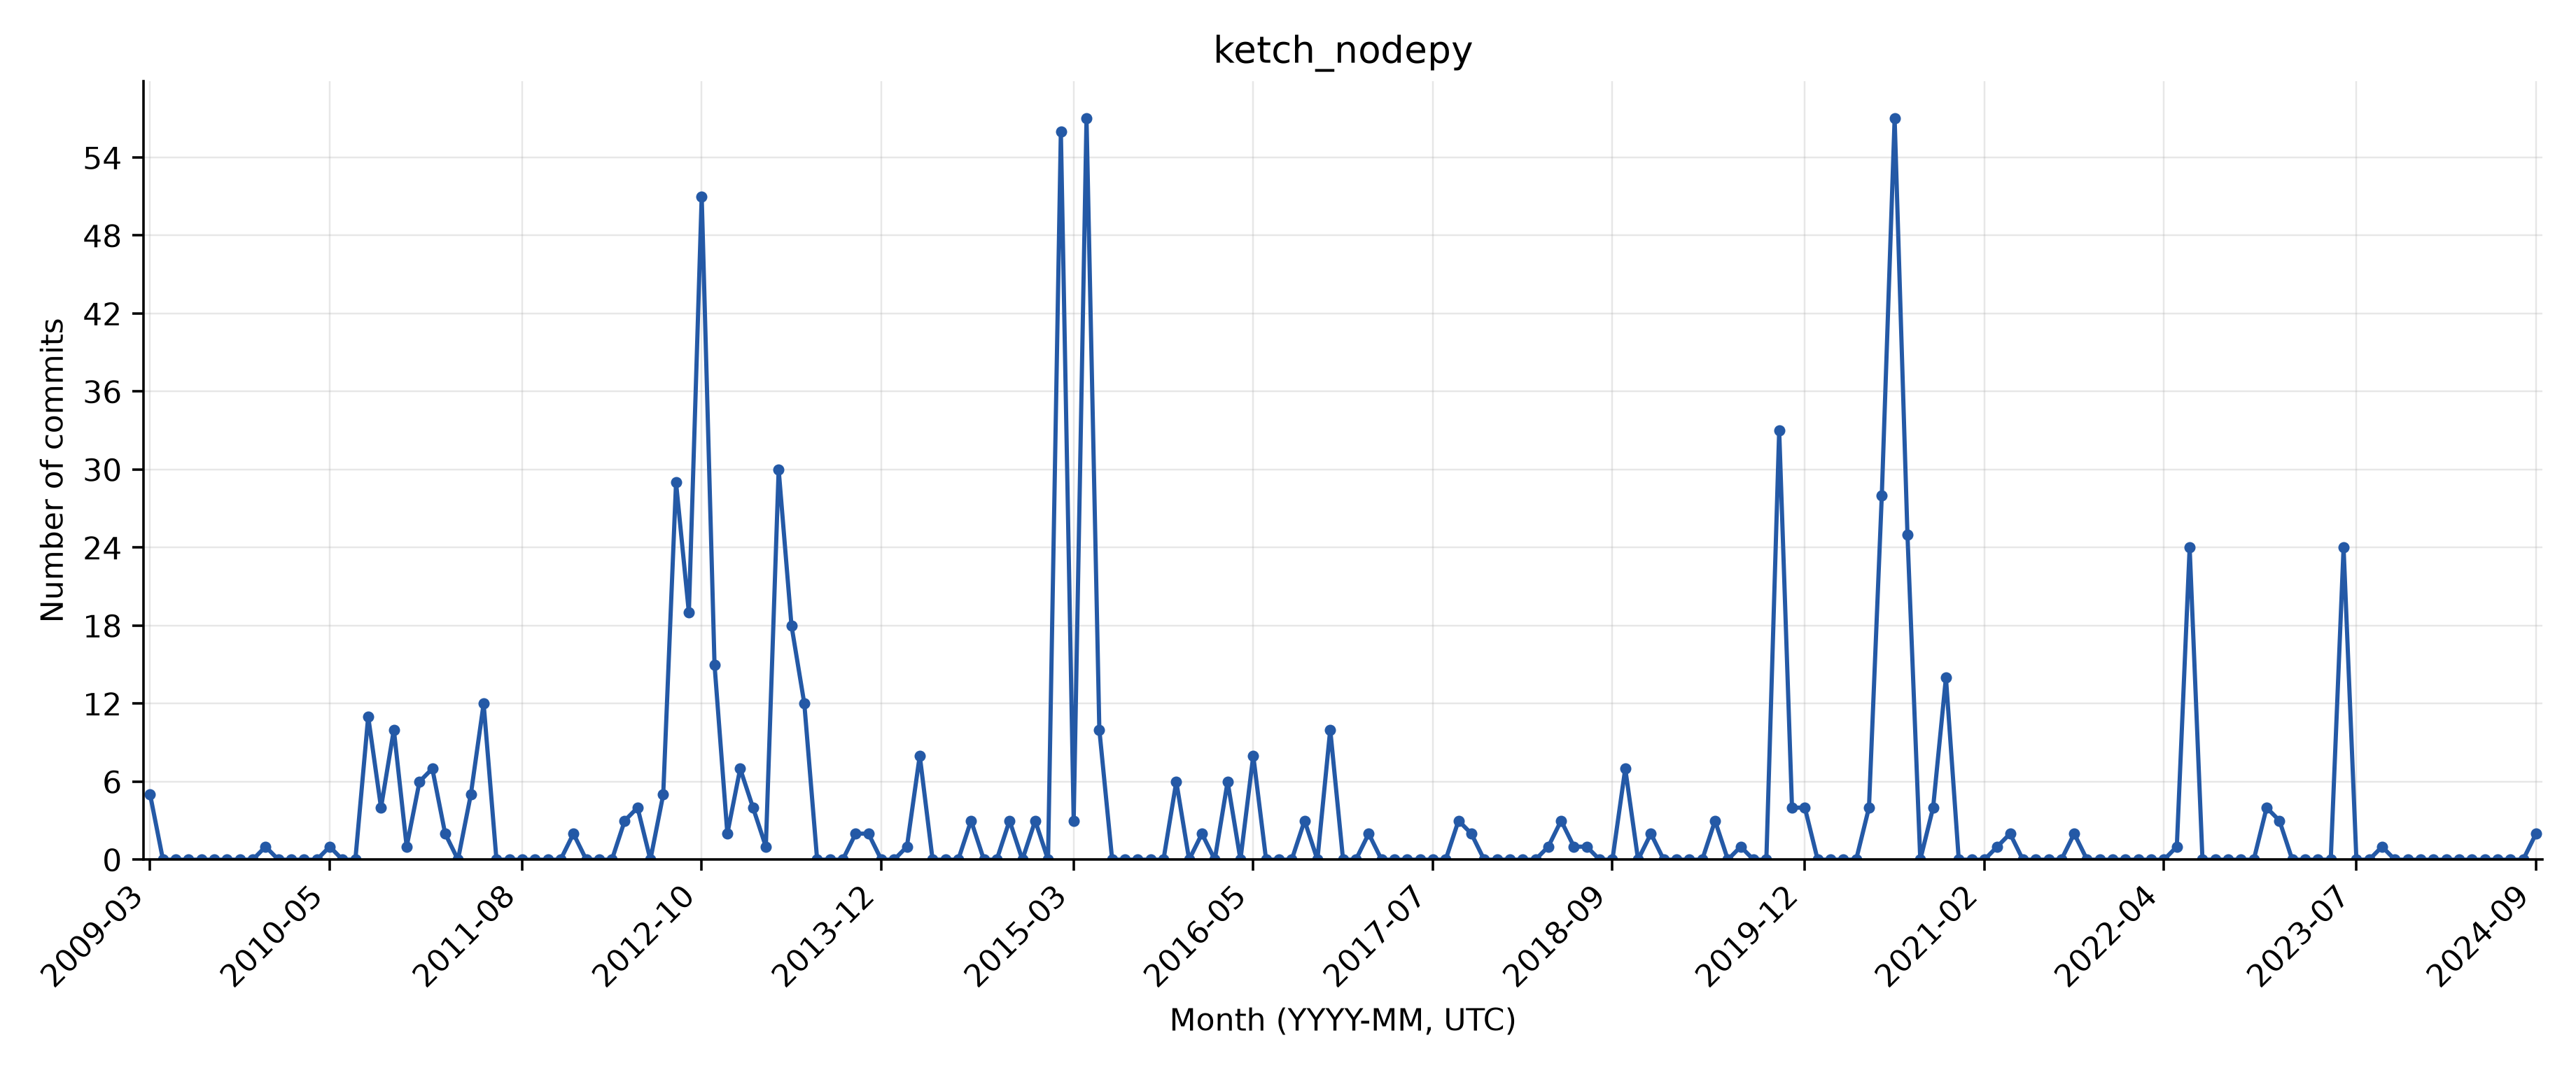

In [8]:
display(Image(filename="dpate172_timeseries_ketch_nodepy.png", width=900))

### mouseland_suite2p

**Pattern: declining**

Activity falls from 1,200 commits in 2020 to 166 in 2021 and 79 in 2024. It increases to 237 in 2025, but remains below the earlier level. There are no gaps of at least three months.

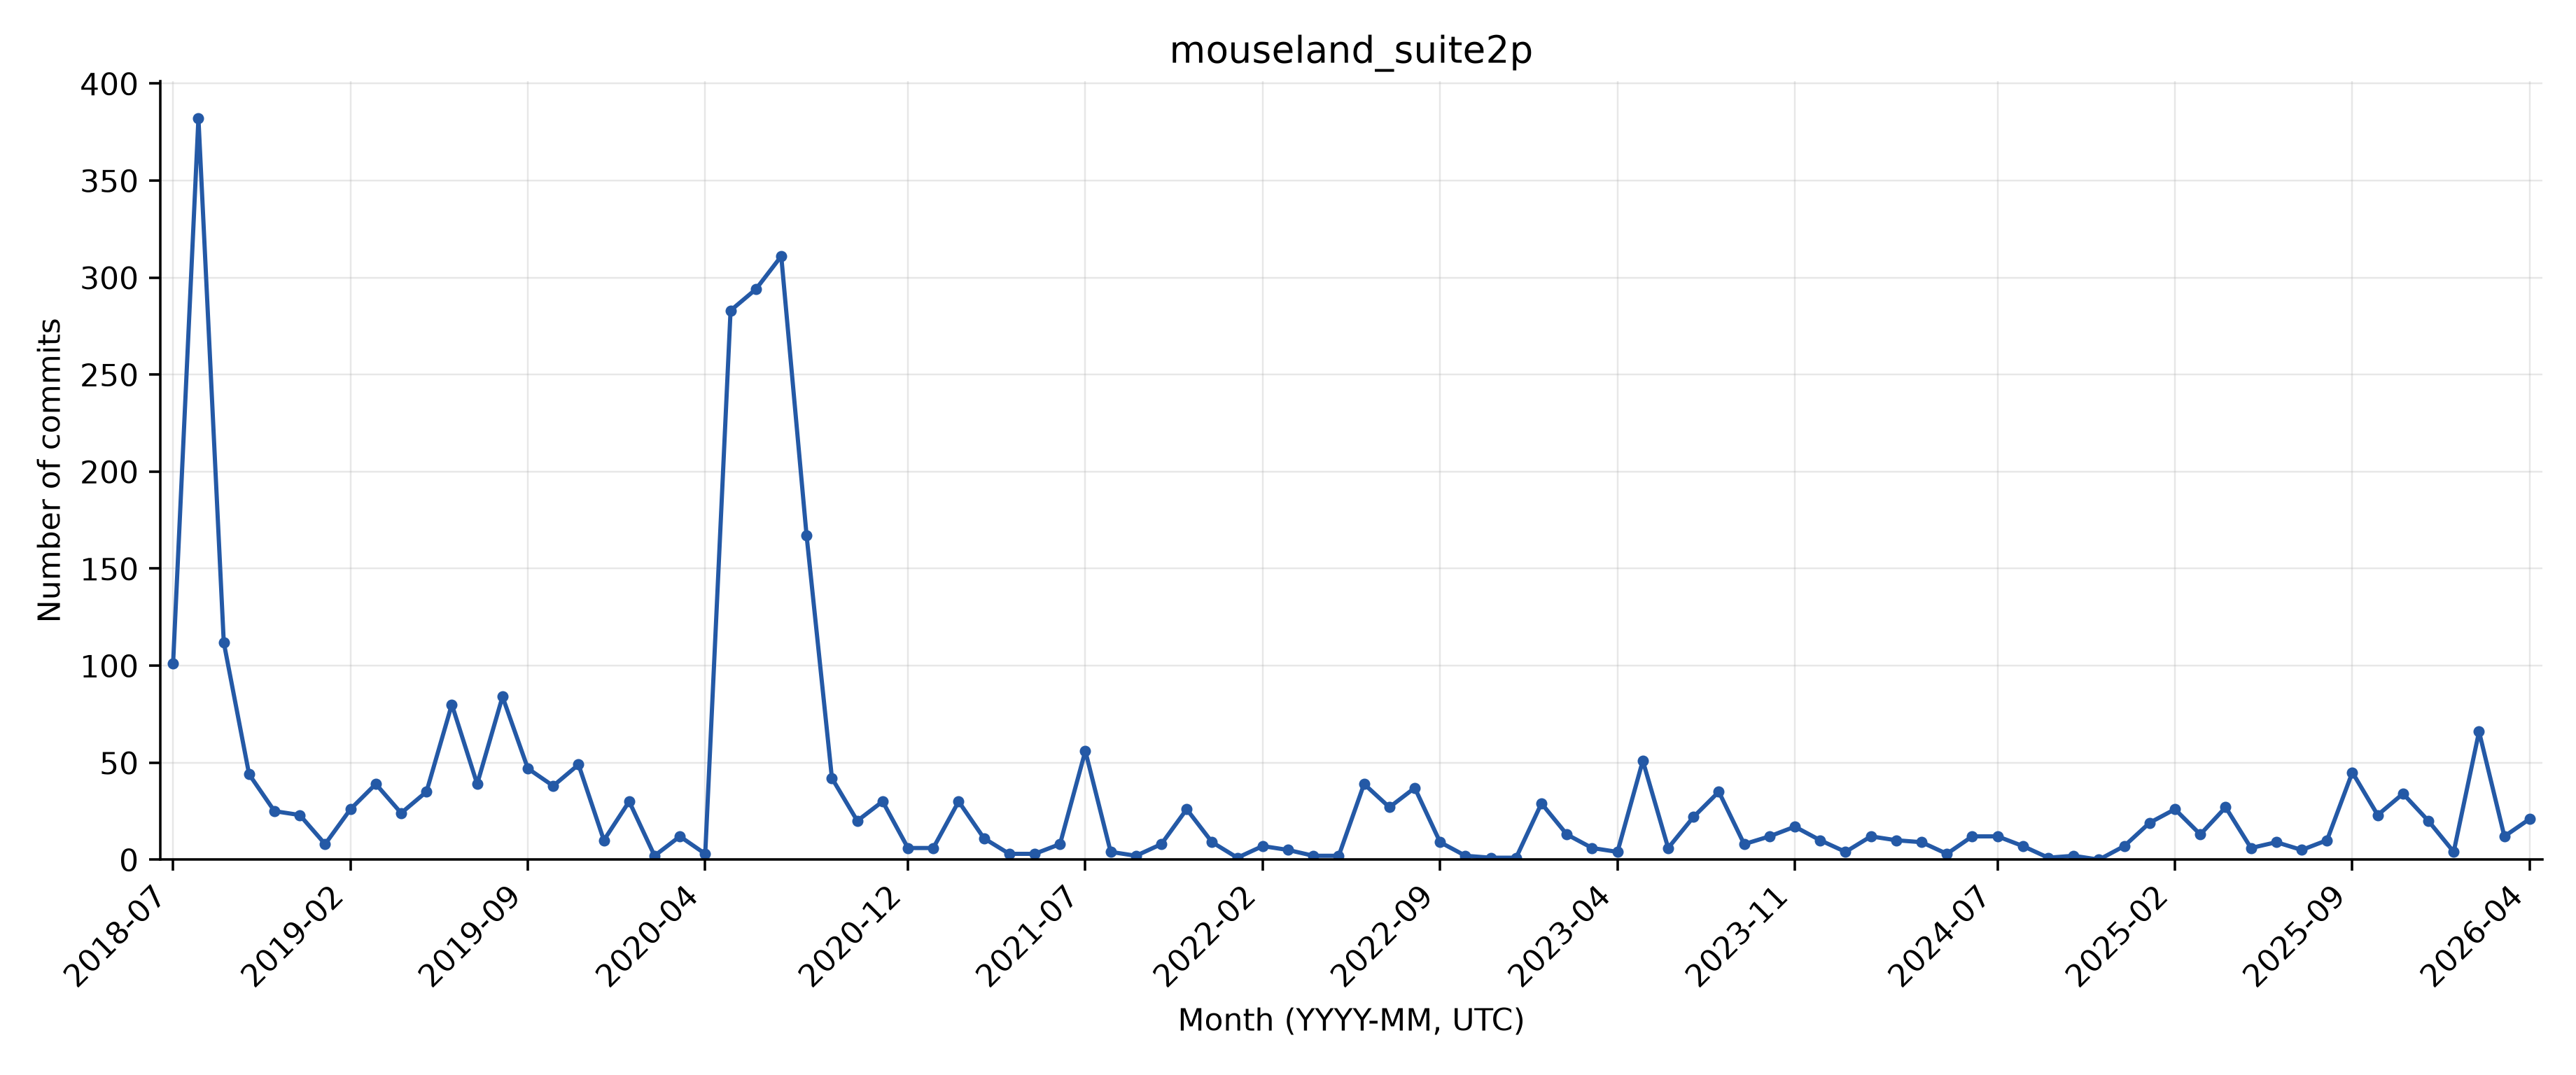

In [9]:
display(Image(filename="dpate172_timeseries_mouseland_suite2p.png", width=900))

### esri_geoportal-server

**Pattern: declining**

Activity is strongest during 2013–2015, reaching 458 commits in 2015, then falls to 4 in 2021 and 7 in 2024. July 2013 is the busiest month with 127 commits. There are 10 gaps of at least three months, with the longest running from November 2024 through June 2025.

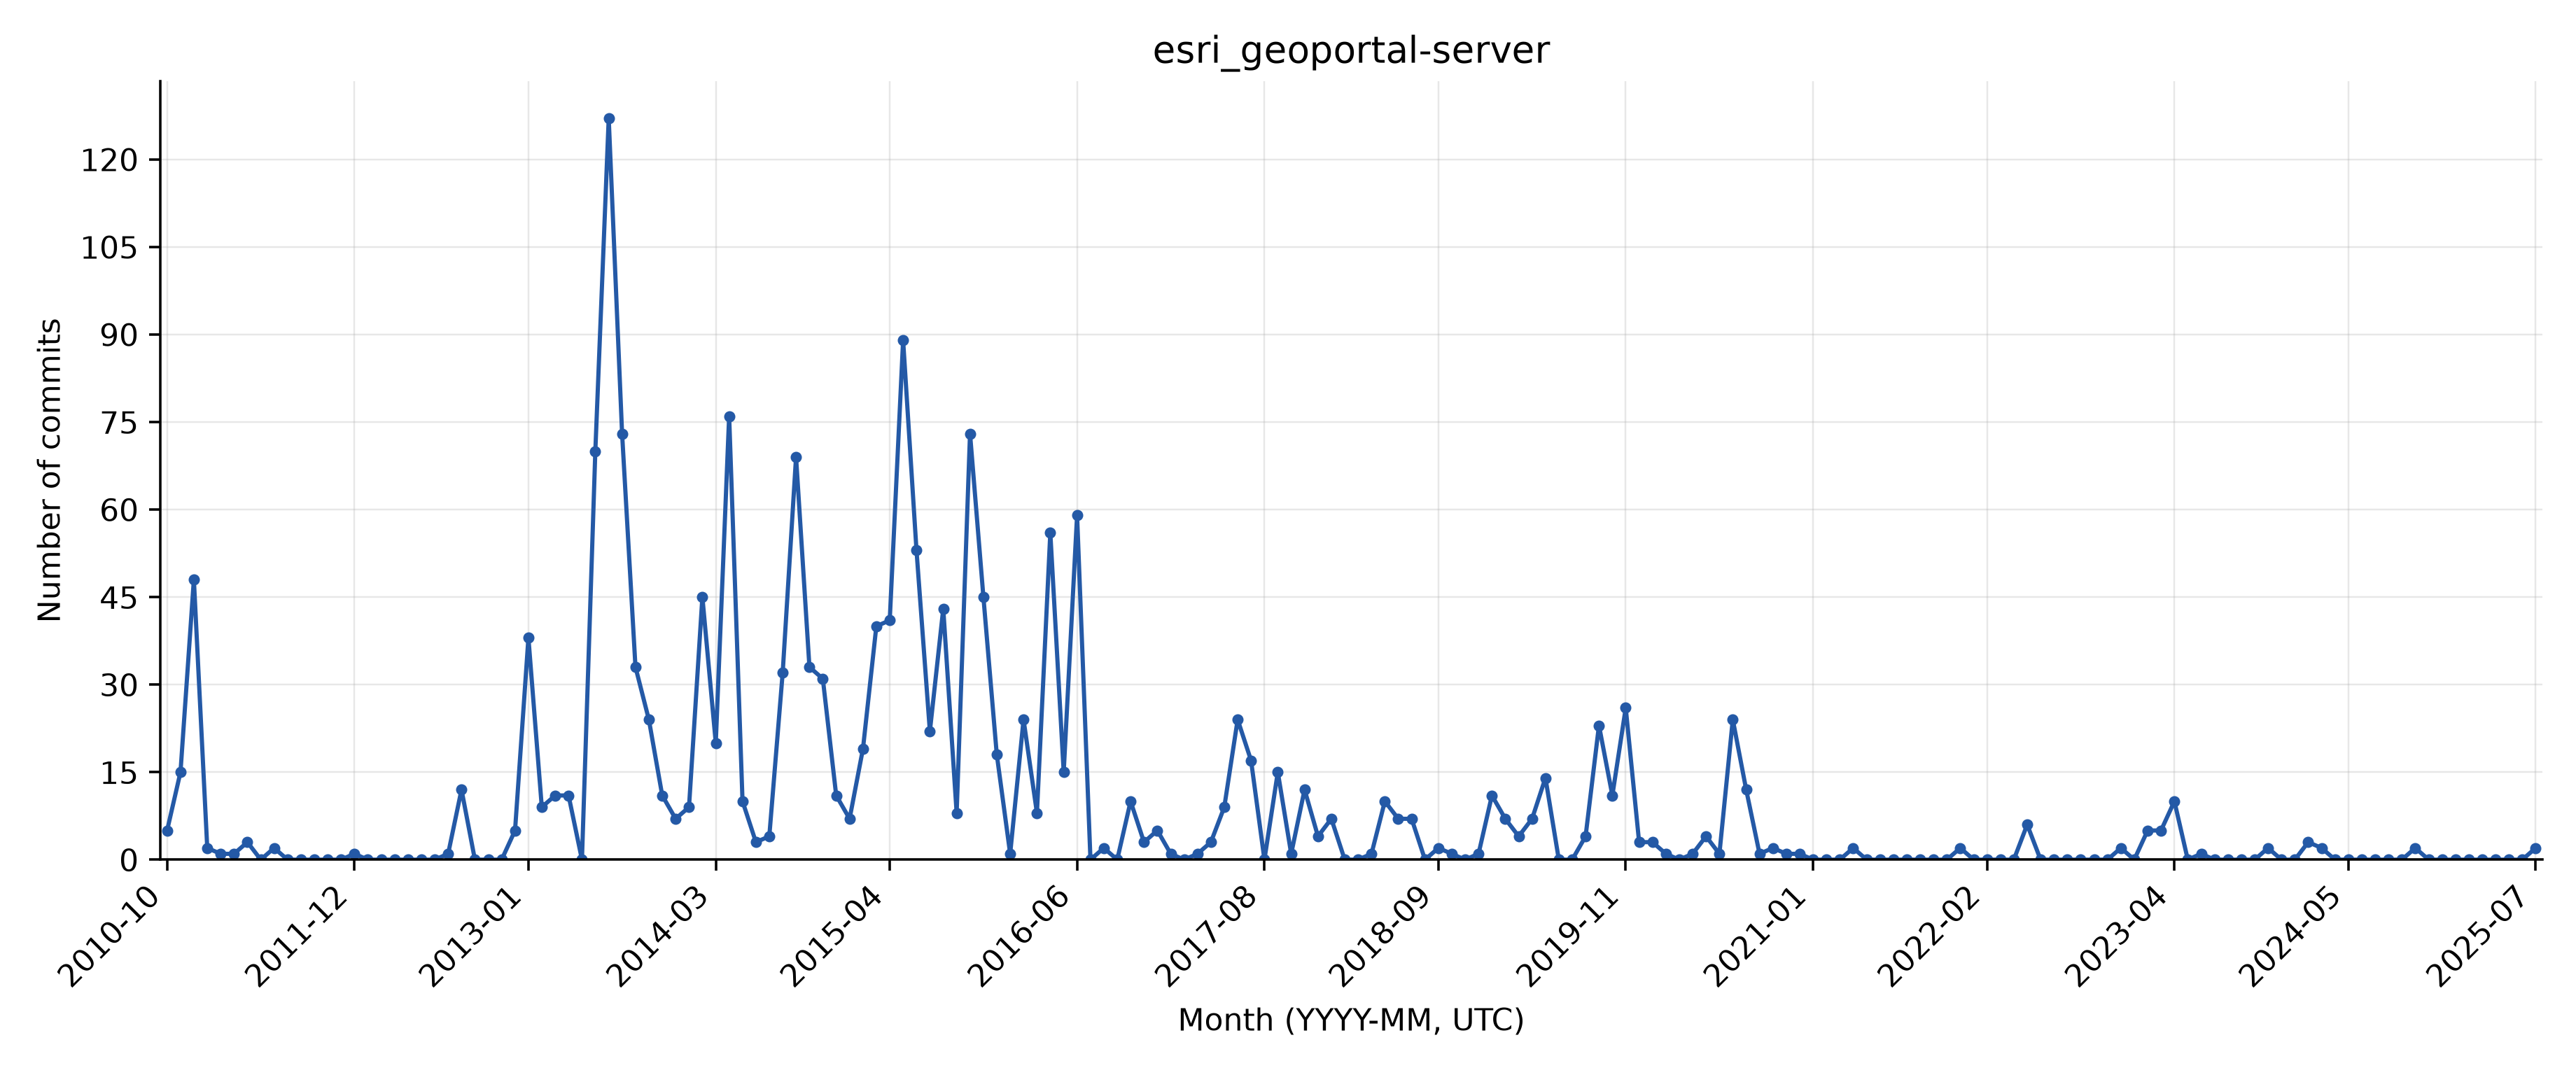

In [10]:
display(Image(filename="dpate172_timeseries_esri_geoportal-server.png", width=900))

### hpparvi_pytransit

**Pattern: irregular**

Activity rises to 313 commits in 2020, falls to 40 in 2022, and rises again to 112 in 2024. There are 9 gaps of at least three months, with the longest lasting seven months during June–December 2015. The 67 commits recorded in January–March 2026 cover only part of that year.

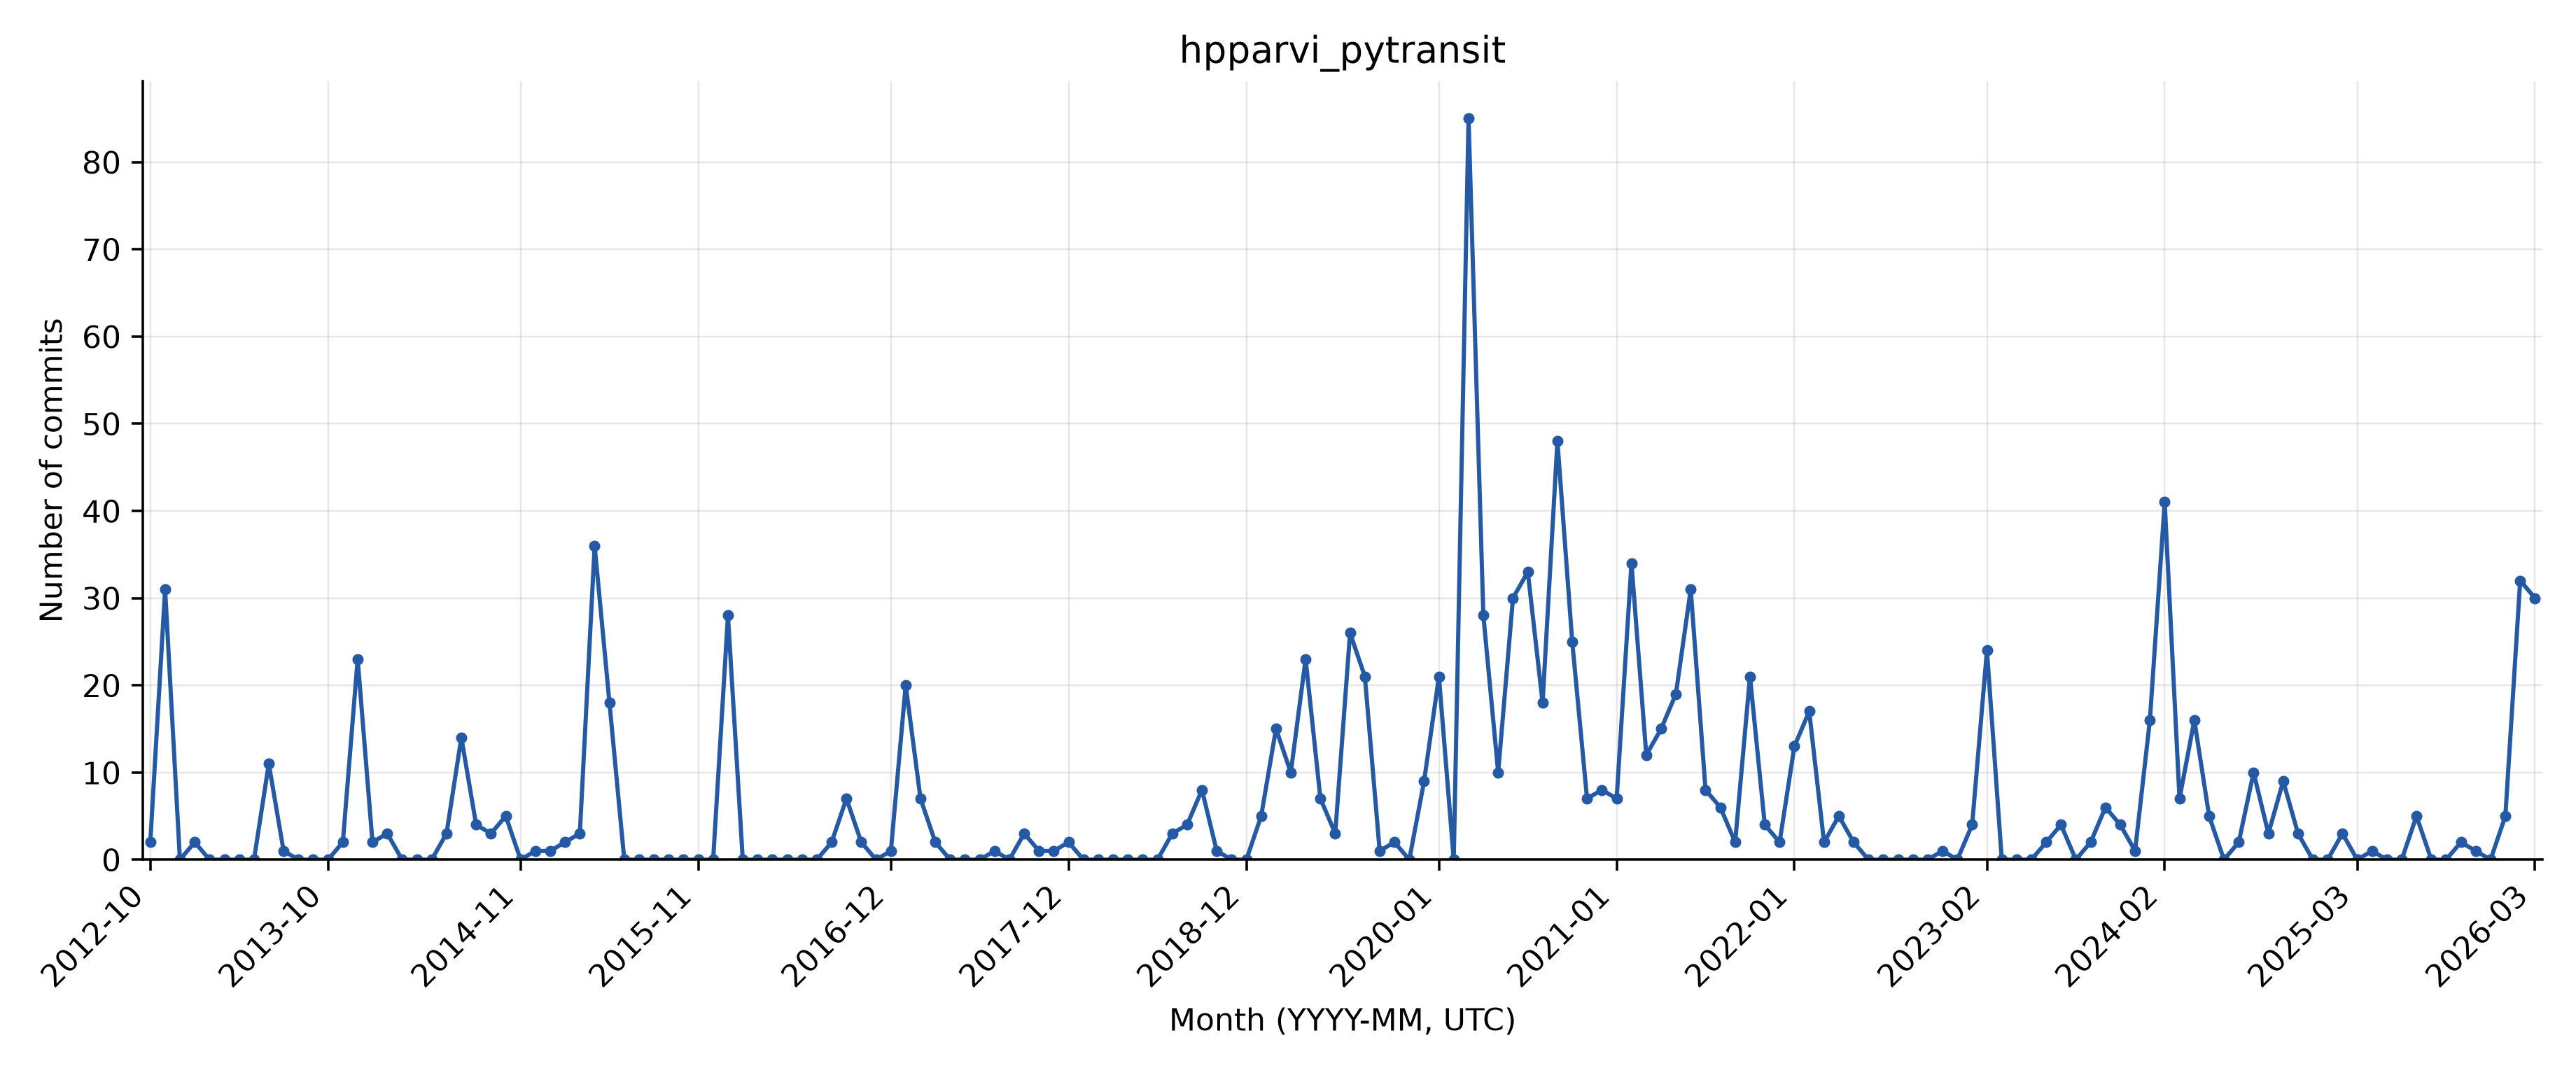

In [11]:
display(Image(filename="dpate172_timeseries_hpparvi_pytransit.png", width=900))

### sundmanbo_opencalphad

**Pattern: declining**

Annual activity falls from 103 commits in 2015 to 11 in 2023. October 2024 has a spike of 41 commits, but this does not form a sustained upward trend. There are 5 gaps of at least three months, with the longest spanning January–May 2024.

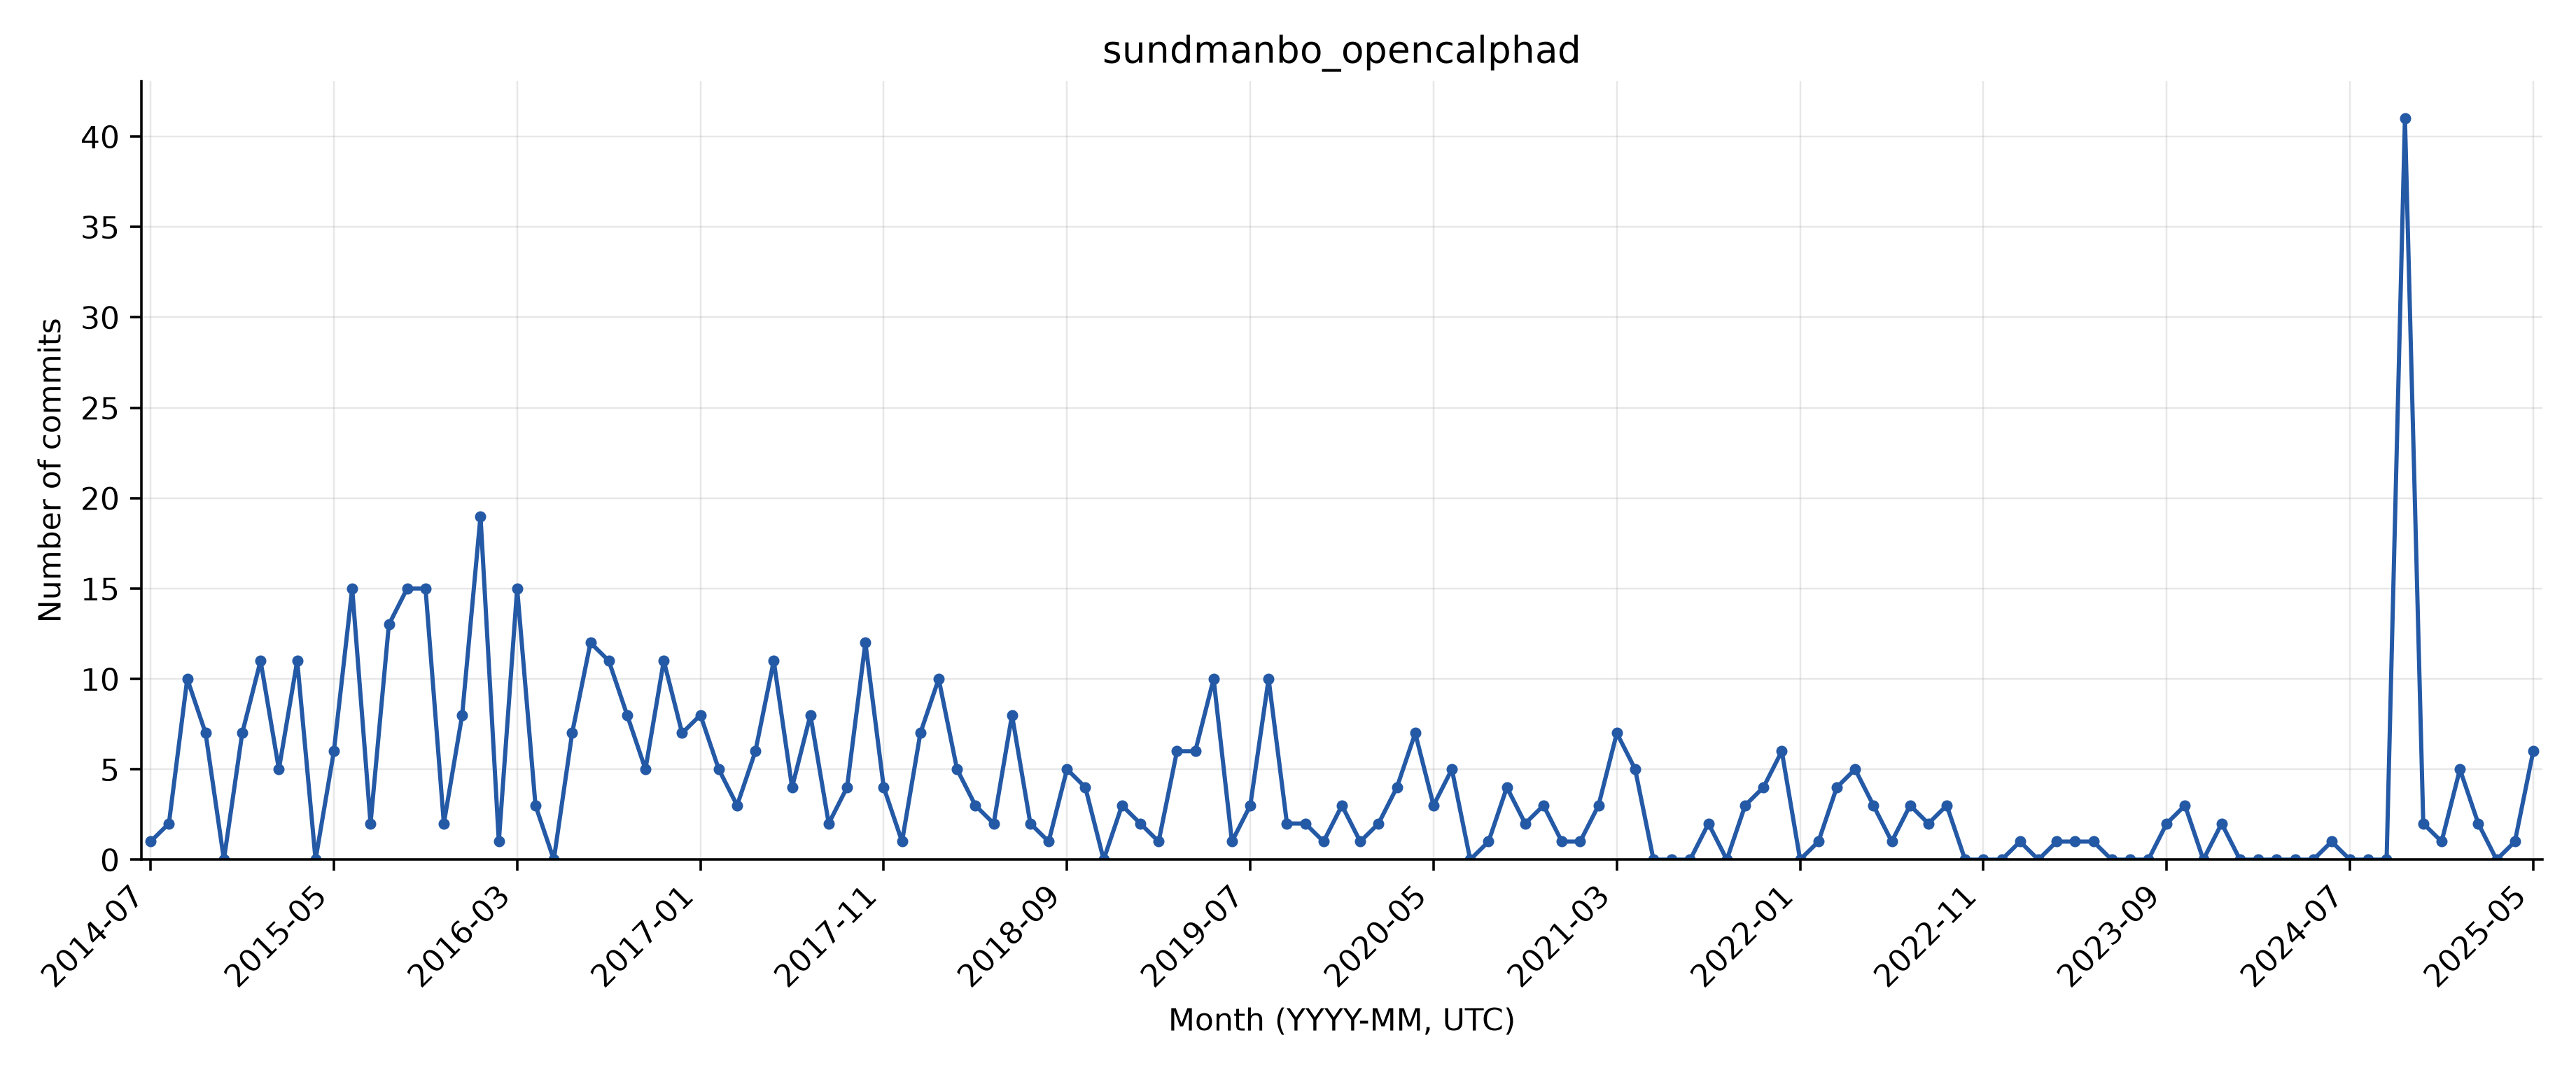

In [12]:
display(Image(filename="dpate172_timeseries_sundmanbo_opencalphad.png", width=900))

### stack-of-tasks_pinocchio

**Pattern: irregular**

Activity moves through several high and low periods, with 1,714 commits in 2018, 668 in 2023, and 1,239 in 2024. The busiest month is August 2018 with 413 commits. There are no gaps of at least three months.

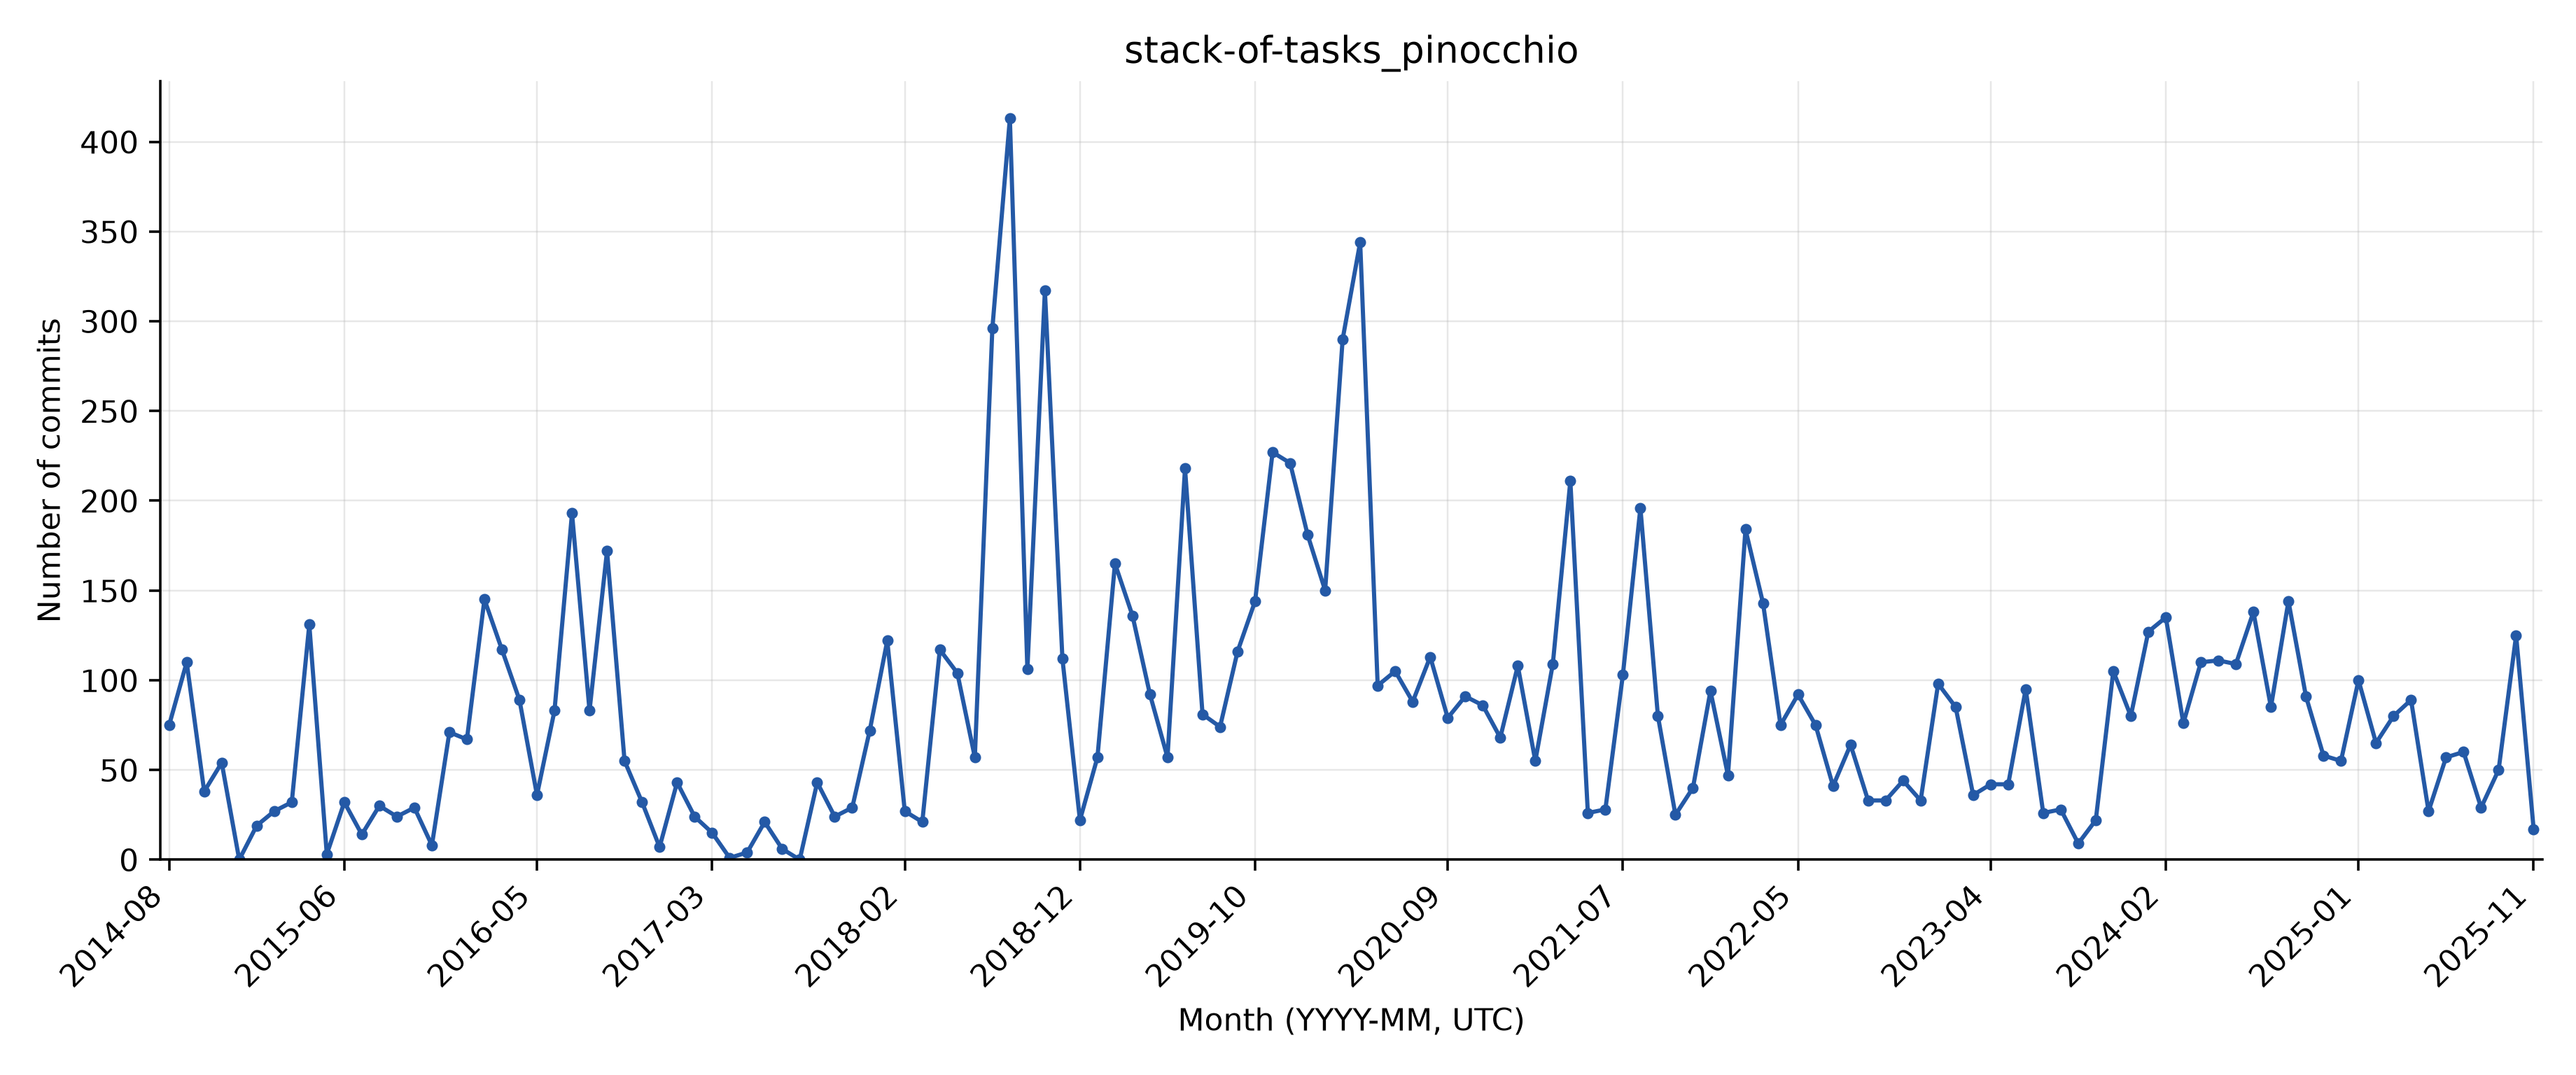

In [13]:
display(Image(filename="dpate172_timeseries_stack-of-tasks_pinocchio.png", width=900))

### microsoft_fhir-server

**Pattern: steady**

Activity stays substantial during 2020–2024, with annual totals between 2,776 and 3,369 commits and a monthly peak of 450 in April 2021. There are no observed gaps of at least three months. The final month ends at the last recorded commit on November 1, 2025, and 12 undated records are excluded, so the low ending point does not establish a decline.

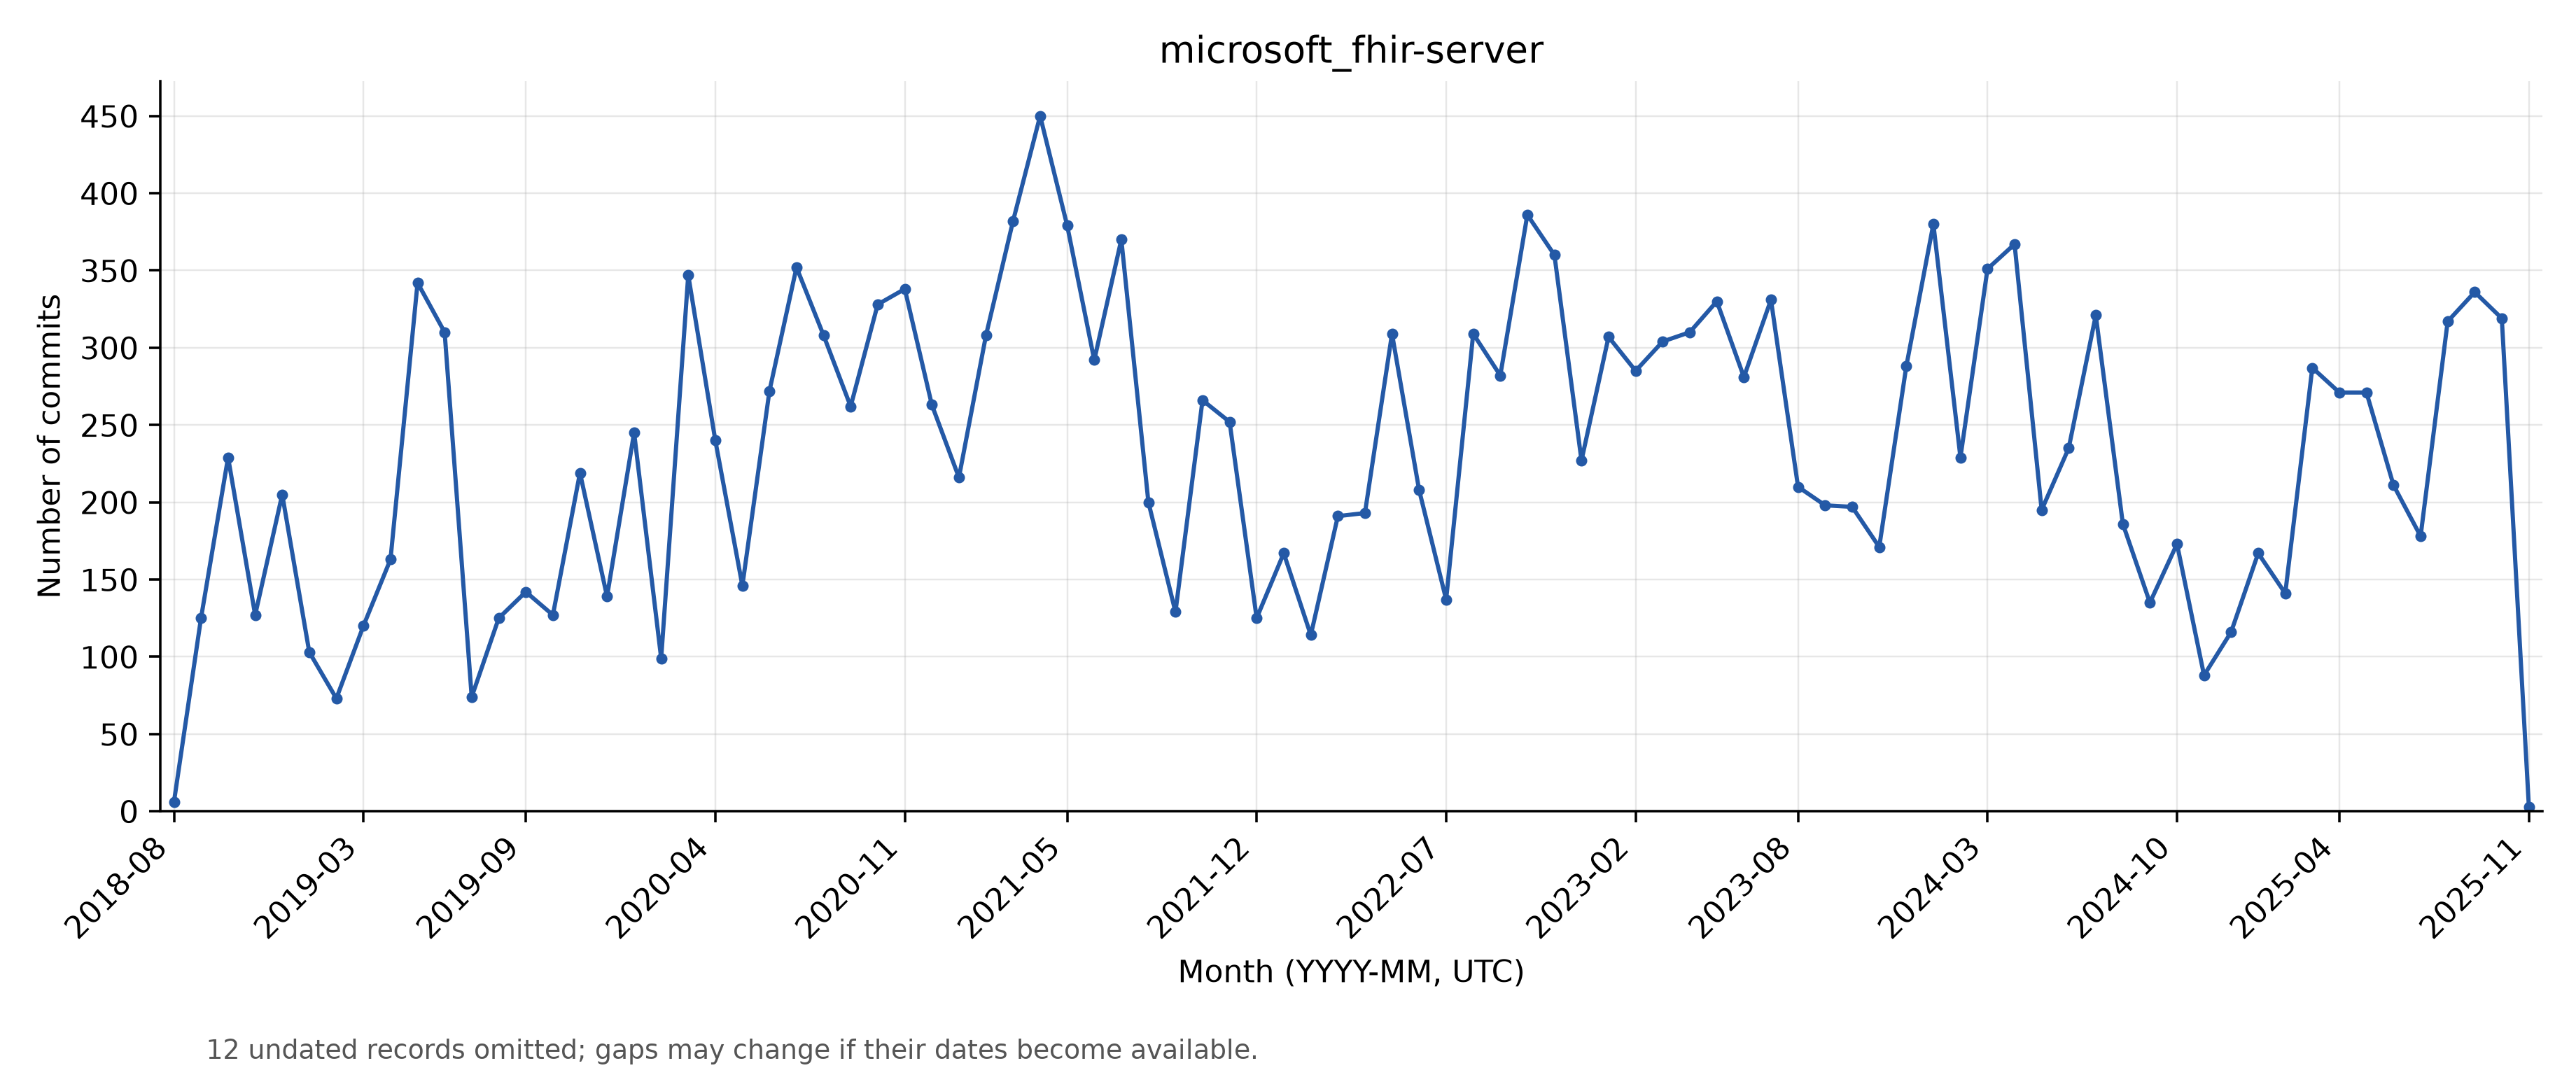

In [14]:
display(Image(filename="dpate172_timeseries_microsoft_fhir-server.png", width=900))

### rapidsai_cucim

**Pattern: declining**

Annual counts decrease from 734 in 2022 to 488 in 2024, then increase to 555 in 2025, so the overall decline is mild. November 2022 is the busiest month with 126 commits. Every observed month has activity, so there are no gaps of at least three months.

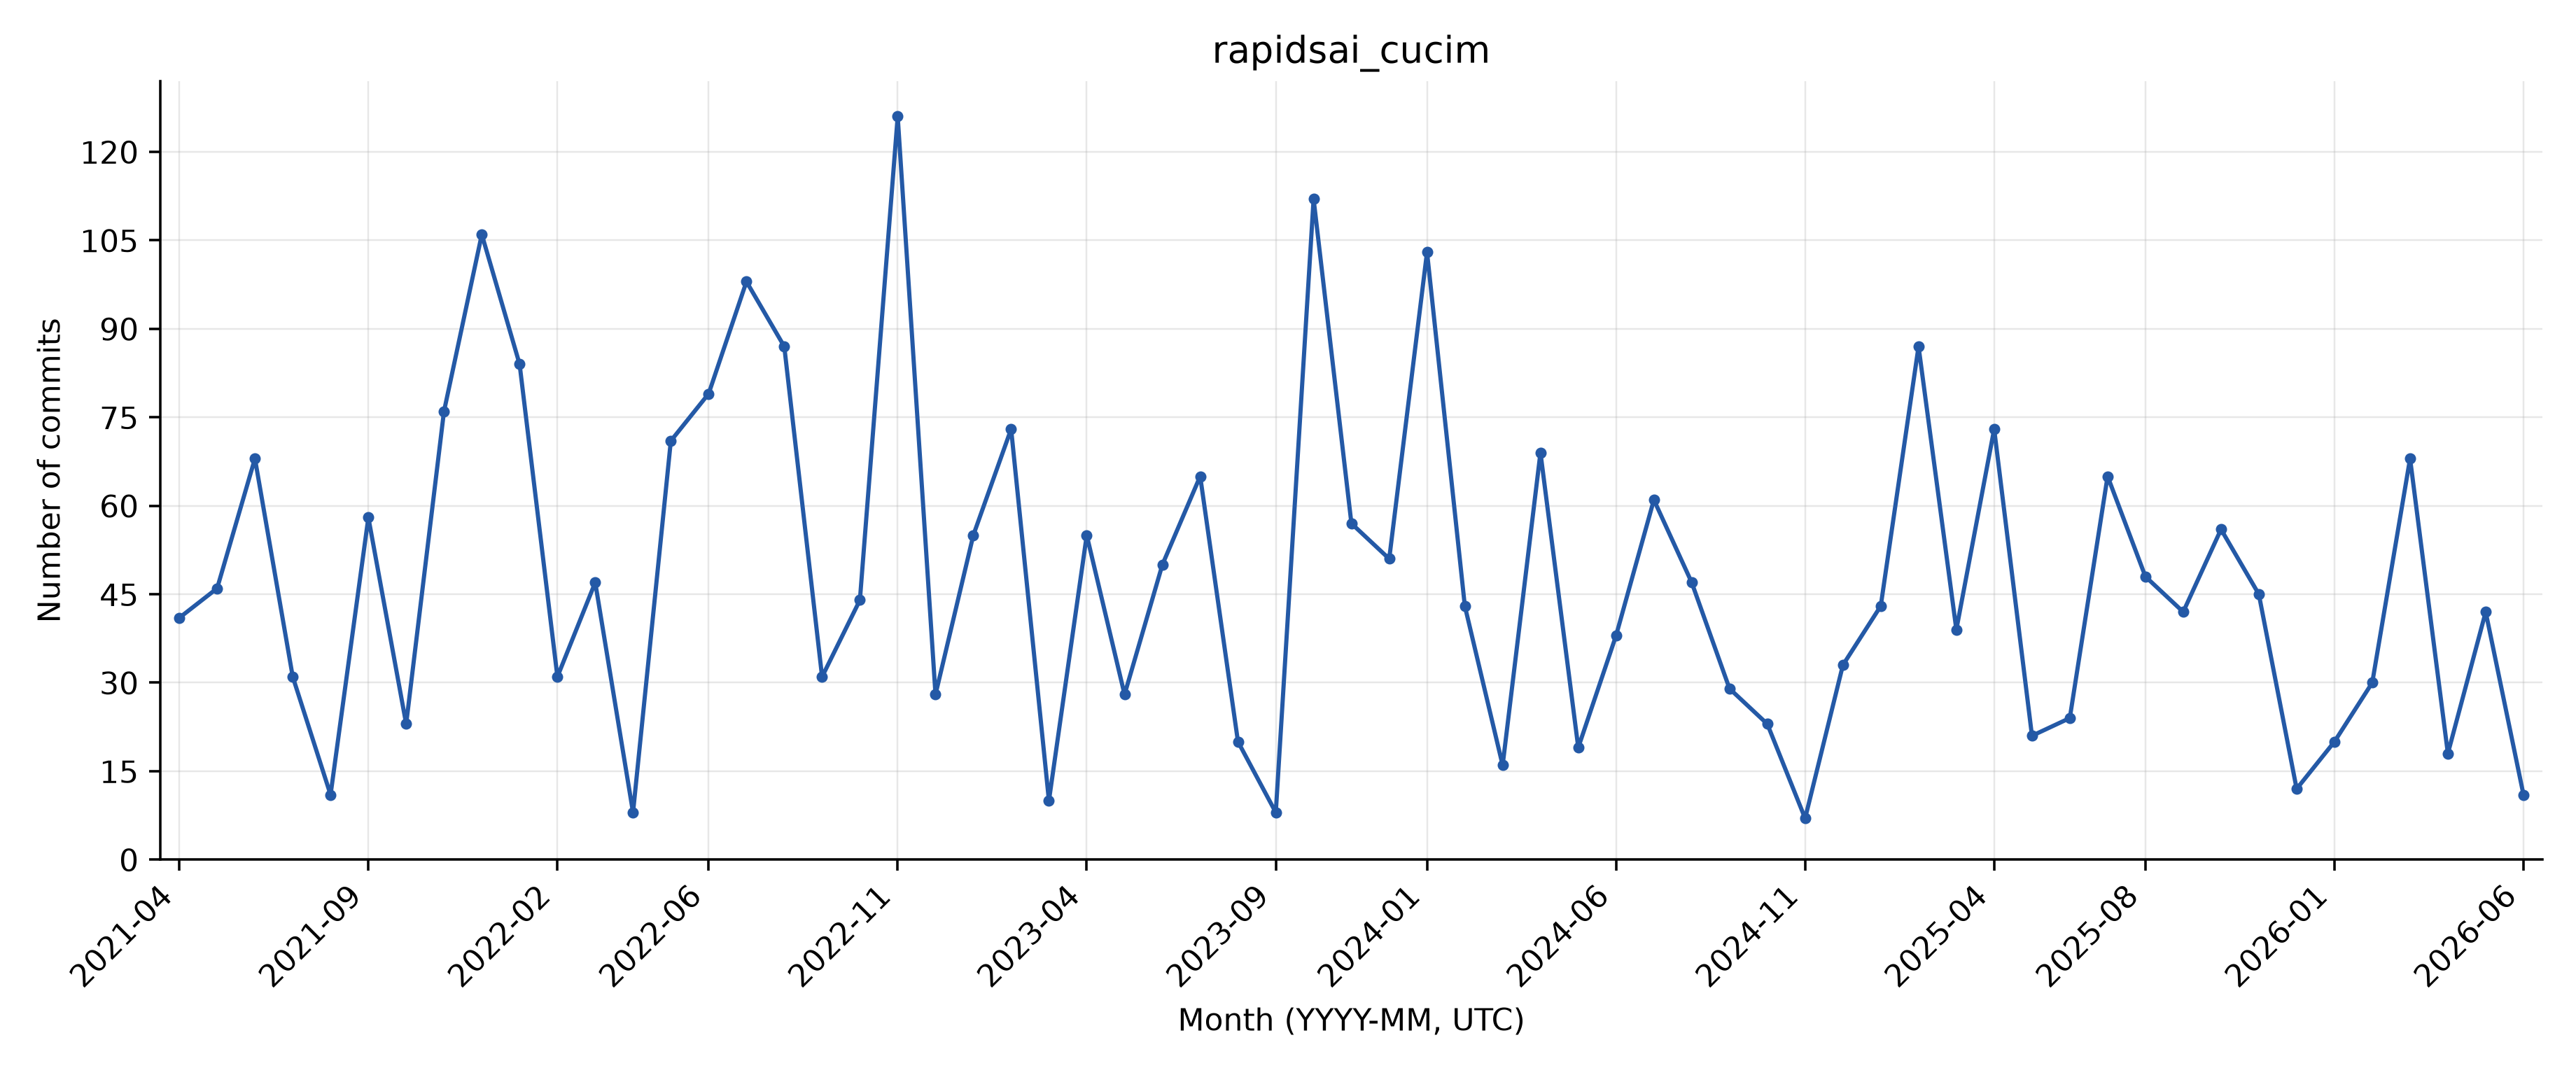

In [15]:
display(Image(filename="dpate172_timeseries_rapidsai_cucim.png", width=900))

### agnwinds_python

**Pattern: irregular**

Activity varies substantially, rising to 672 commits in 2018, dropping to 275 in 2022, and increasing to 355 in 2023. The busiest month is May 2020 with 134 commits, and there are no observed gaps of at least three months. One record lacks a timestamp, so the two-month longest observed gap and the monthly counts may change if its date becomes available.

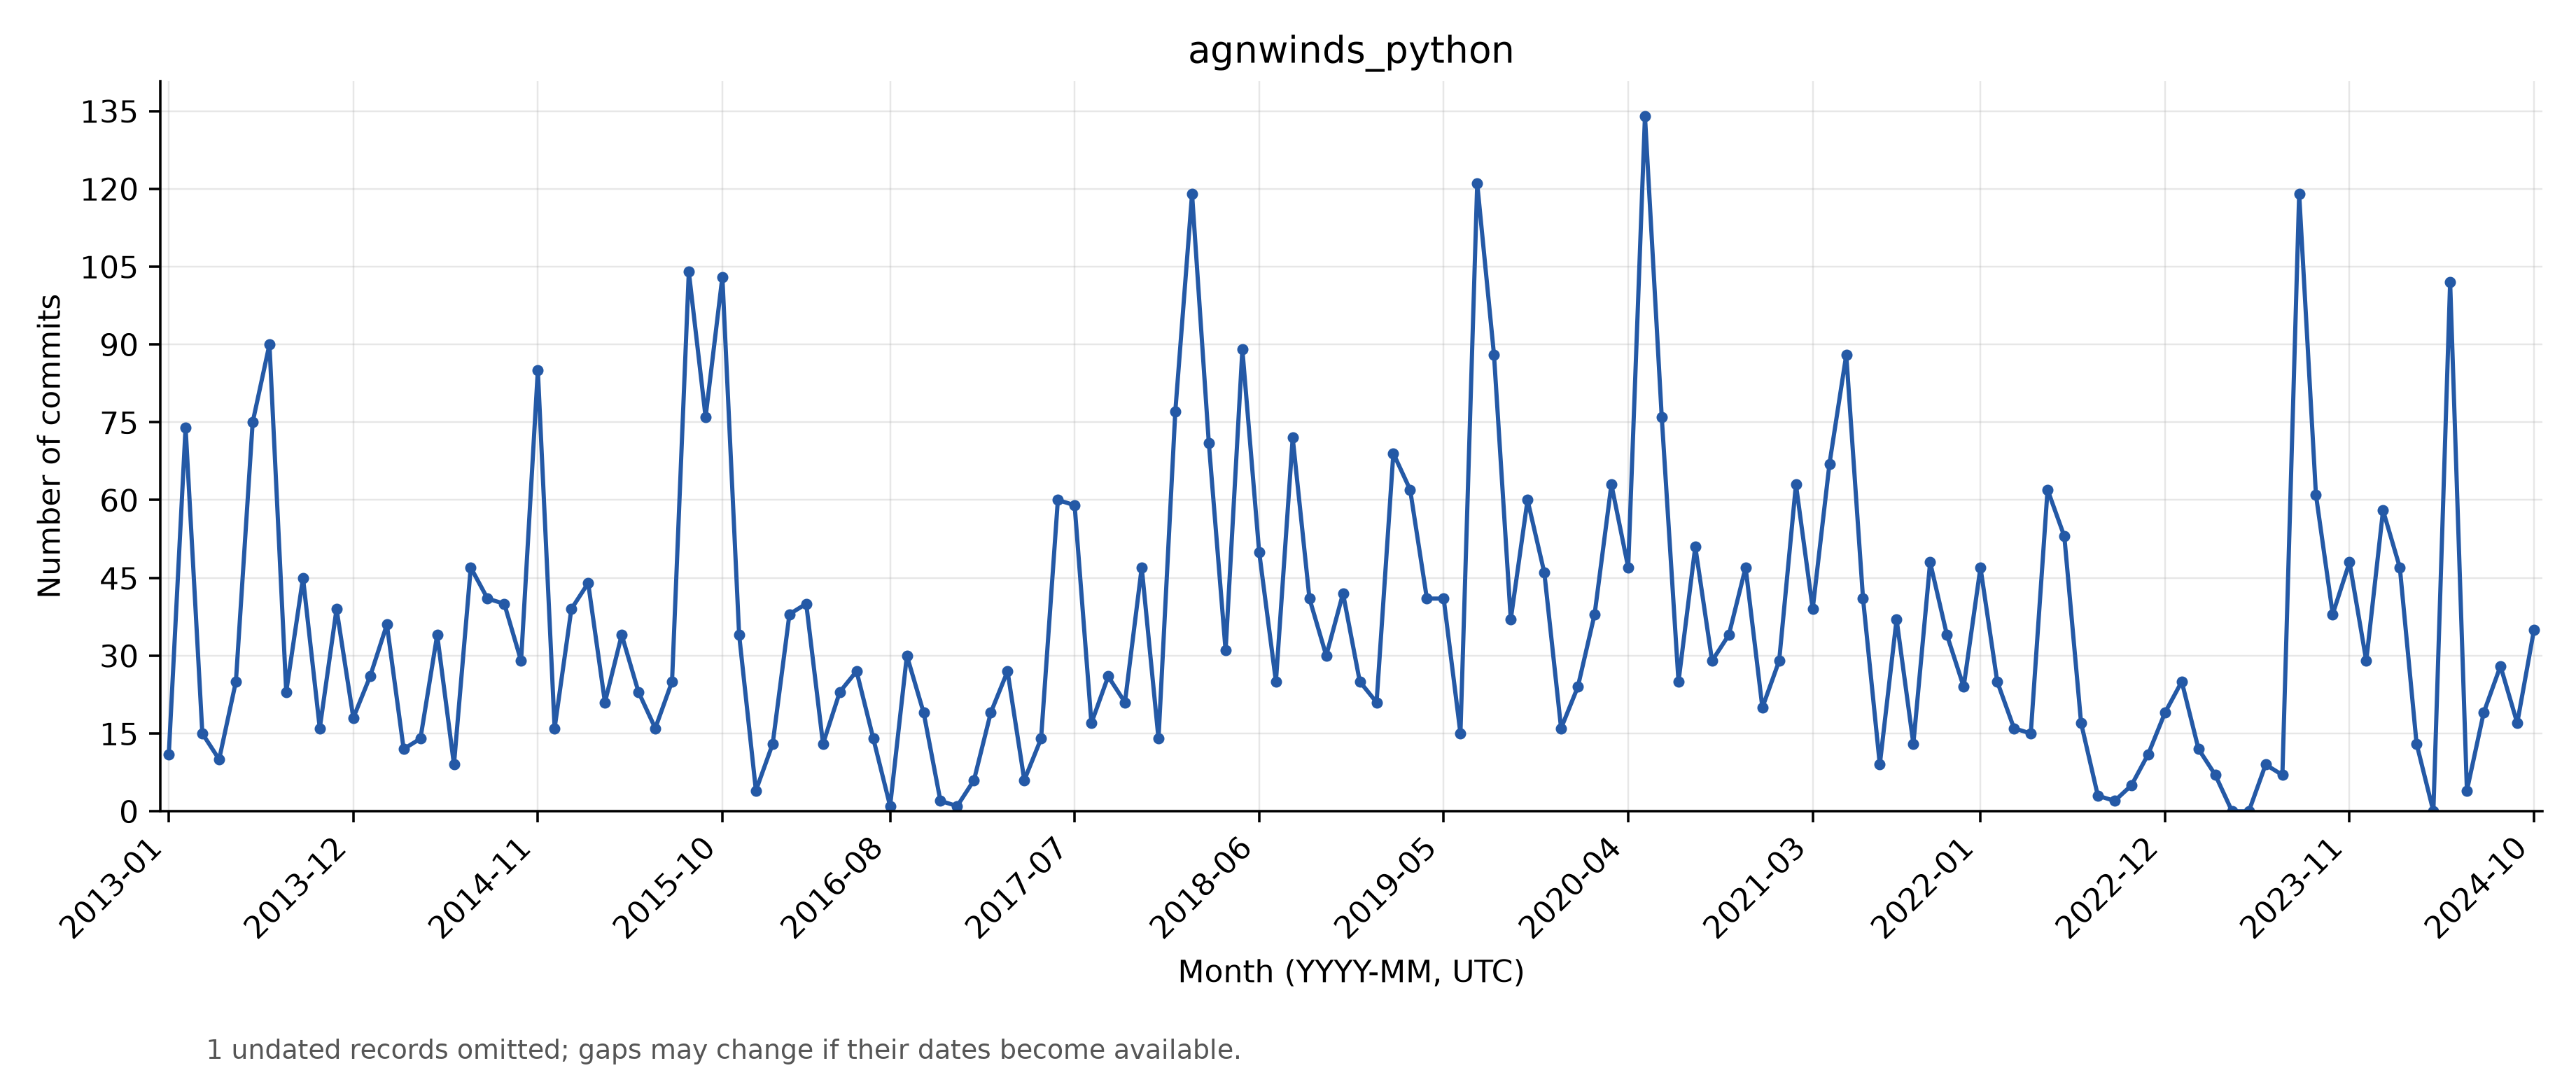

In [16]:
display(Image(filename="dpate172_timeseries_agnwinds_python.png", width=900))

### csgillespie_powerlaw

**Pattern: declining**

Activity drops from 231 commits in 2013 to 29 in 2020 and 2 in 2021. There are 8 gaps of at least three months, with the longest lasting 25 months from December 2021 through December 2023. The final observed month, February 2025, contains 17 commits.

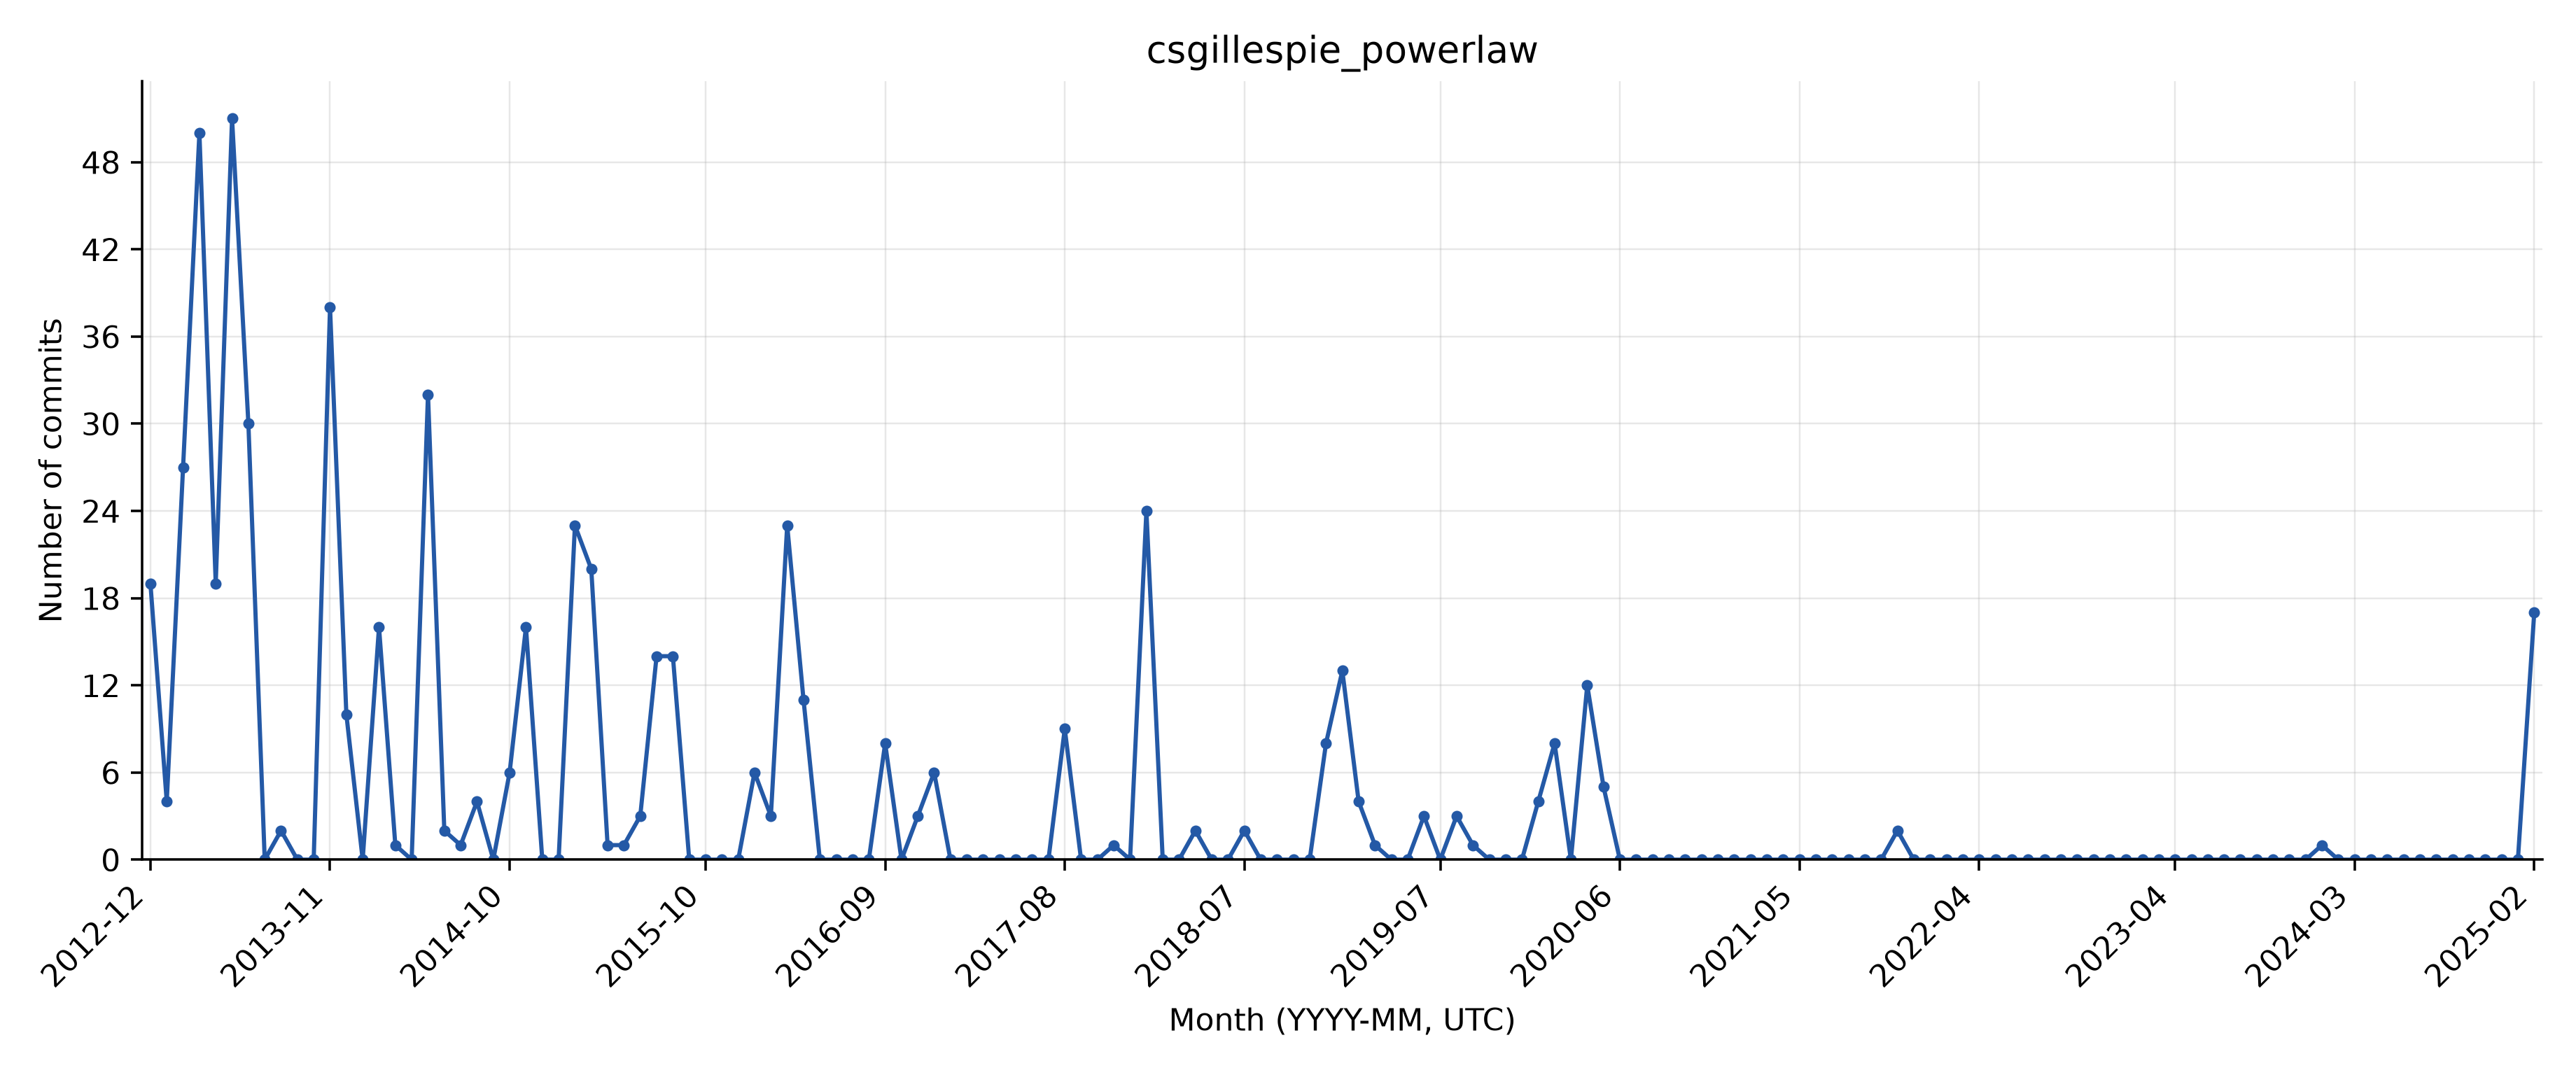

In [17]:
display(Image(filename="dpate172_timeseries_csgillespie_powerlaw.png", width=900))

## Saved files

- `dpate172_commits_timeseries_<WOCProjectID>.csv`: one monthly table per project.
- `dpate172_timeseries_<WOCProjectID>.png`: one 320-DPI plot per project.
- [dpate172_project_stats.csv](dpate172_project_stats.csv): Part 1 values plus the six Part 2 columns.

Running this notebook regenerates the Part 2 files. Existing Part 3 columns are
preserved only when the first fourteen statistics columns are unchanged.
Otherwise, it stops so outdated Part 3 explanations are not kept.
If Part 1 is collected again, review and rerun the later parts. A changed Part 1
baseline also needs a reviewed replacement for `data/dpate172_part1_stats.csv`,
which keeps the original statistics.